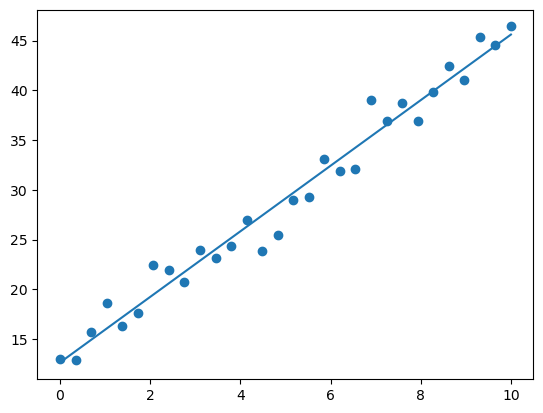

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
# This ensures your random data matches mine exactly
np.random.seed(42)

# Generate your experimental variables
x_data = np.linspace(0, 10, 30)
noise = np.random.normal(0, 2.0, size=x_data.size)
y_data = 3.5 * x_data + 12.0 + noise

# clear out temporary math variables so you can't see the true values
del noise
plt.scatter(x_data,y_data)
fun=lambda x,a,b: a*x+b
[[a,b],_]=curve_fit(fun,x_data,y_data)
x=np.linspace(0,10,1000)
plt.plot(x,fun(x,a,b))

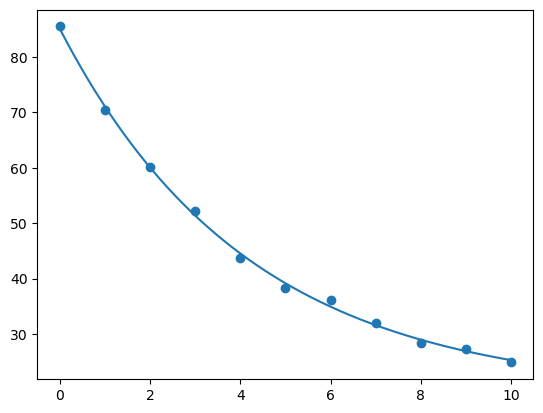

In [23]:
import numpy as np

np.random.seed(42)

# Sparse observations over 10 seconds (e.g., recorded once per second)
t_data = np.linspace(0, 10, 11)
true_signal = 20.0 + (85.0 - 20.0) * np.exp(-0.25 * t_data)
T_data = true_signal + np.random.normal(0, 1.0, size=t_data.size)

# Assume the starting temperature is a known constant
T_start = 85.0 
def euler_method(t_data,k,T_env):
    dt=0.001
    t_sim=np.arange(0,10,dt)
    T=np.zeros(len(t_sim))
    T[0]=85.0
    for i in range(len(t_sim)-1):
        v=-k*(T[i]-T_env)
        T[i+1]=T[i]+v*dt
    if t_data is not None:
        return np.interp(t_data, t_sim, T)
    return t_sim, T
plt.scatter(t_data,T_data)
[[k,T_env],_]=curve_fit(euler_method,t_data,T_data,p0=[0.1,15])

t_sim,T=euler_method(None,k,T_env)
plt.plot(t_sim,T)

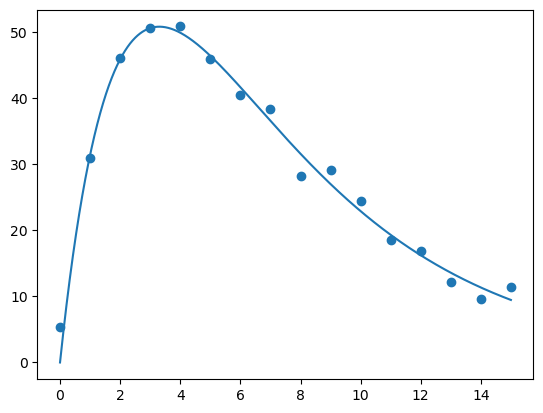

In [24]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(101)

# Experimental time tracking over 15 seconds
t_data = np.linspace(0, 15, 16)

# Hidden True Parameters: A_start=100.0, k1=0.4, k2=0.2
true_A = 100.0 * np.exp(-0.4 * t_data)
true_B = (0.4 * 100.0 / (0.2 - 0.4)) * (np.exp(-0.4 * t_data) - np.exp(-0.2 * t_data))
B_sensor_data = true_B + np.random.normal(0, 2.0, size=t_data.size)

# Clear hidden verification variables
del true_A, true_B

plt.scatter(t_data,B_sensor_data)

def coupled_euler(t_data,Astart,k1,k2):
    dt=0.001
    t_sim=np.arange(0,15,dt)
    A,B=np.zeros(len(t_sim)),np.zeros(len(t_sim))
    A[0],B[0]=Astart,0
    for i in range(len(t_sim)-1):
        v_A=-k1*A[i]
        A[i+1]=A[i]+v_A*dt
        v_B=k1*A[i]-k2*B[i]
        B[i+1]=B[i]+v_B*dt
    if t_data is not None:
        return np.interp(t_data,t_sim,B)
    return t_sim,B
[[Astart,k1,k2],_]=curve_fit(coupled_euler,t_data,B_sensor_data,p0=[80.0, 0.1, 0.1])
t_sim,B=coupled_euler(None,Astart,k1,k2)
plt.plot(t_sim,B)

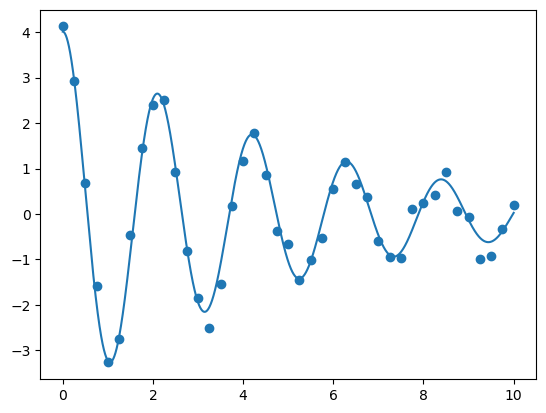

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

np.random.seed(42)

# Sensor captures position every 0.25 seconds
t_data = np.linspace(0, 10, 41)

# Hidden true parameters: x0=4.0, v0=0.0, b/m=0.4, k/m=9.0
omega = np.sqrt(9.0 - (0.4/2)**2)
true_x = 4.0 * np.exp(-0.2 * t_data) * (np.cos(omega * t_data) + (0.2/omega) * np.sin(omega * t_data))
x_sensor_data = true_x + np.random.normal(0, 0.25, size=t_data.size)

del omega, true_x
plt.scatter(t_data,x_sensor_data)

def oscilator_euler(t_data,c,w,x0):
    dt=0.0001
    t=np.arange(0,10,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0],v[0]=x0,0
    for i in range(len(t)-1):
        a=-c*v[i]-w*x[i]
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
[[c,w,x0],_]=curve_fit(oscilator_euler,t_data,x_sensor_data,p0=[1,1,4])
t,x=oscilator_euler(None,c,w,x0)
plt.plot(t,x)

2.4351630472824266 2.0302721645582147


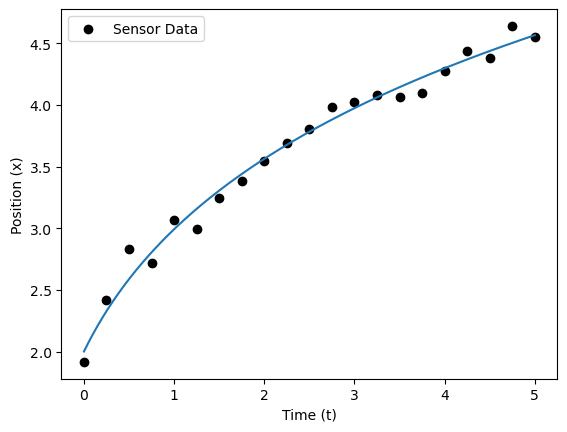

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import k1  # This is the K1 function in your equation
from scipy.optimize import curve_fit

# This ensures your dataset is perfectly consistent
np.random.seed()

# Sparse observational times over 5 seconds
t_data = np.linspace(0, 5, 21)

# Hidden True Parameters: A = 1.5, B = 2.5, x0 = 2.0
# Generating synthetic trajectory using a high-precision solver
def true_system(t):
    dt = 0.0005
    t_sim = np.arange(0, 5 + dt, dt)
    x = np.zeros(len(t_sim))
    x[0] = 2.0  # x0
    for i in range(len(t_sim) - 1):
        # dx/dt = A * K1(x/B)
        dxdt = 1.5 * k1(x[i] / 2.5)
        x[i+1] = x[i] + dxdt * dt
    return np.interp(t, t_sim, x)

# Generate tracking data with random sensor noise
x_sensor_data = true_system(t_data) + np.random.normal(0, 0.15, size=t_data.size)

# Clear underlying generation math out of memory
del true_system

# Display your raw experimental scatter points
plt.scatter(t_data, x_sensor_data, color='black', label='Sensor Data')
plt.xlabel('Time (t)')
plt.ylabel('Position (x)')
plt.legend()


def cheerios_euler_fit(t_data,A,B):
    dt=0.0001
    t=np.arange(0,5,dt)
    x=np.zeros(len(t))
    x[0]=2
    for i in range(len(t)-1):
        v=A*k1(x[i]/B)
        x[i+1]=x[i]+v*dt
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
[[A,B],_]=curve_fit(cheerios_euler_fit,t_data,x_sensor_data,p0=[1.5,2.5])
t,x=cheerios_euler_fit(None,A,B)
plt.plot(t,x)
print(A,B)

0.37395411228215325 4.250315311922381


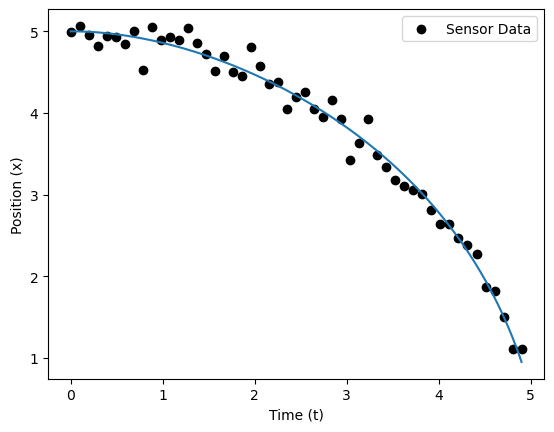

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import k1
from scipy.optimize import curve_fit

#AI genrated data to test the fit
np.random.seed()

t_data = np.linspace(0, 4.9, 51)

def generate_nonlinear_system(t):
    dt = 0.0001
    t_sim = np.arange(0, 10 + dt, dt)
    x = np.zeros(len(t_sim))
    v = np.zeros(len(t_sim))
    
    x[0], v[0] = 5.0, 0.0
    for i in range(len(t_sim) - 1):
        dv = -0.3 * v[i] - 4.0 * k1(x[i] / 2.0)
        v[i+1] = v[i] + dv * dt
        x[i+1] = x[i] + v[i+1] * dt 
        
    return np.interp(t, t_sim, x)

# Generate tracking position points containing artificial sensor noise
x_sensor_data = generate_nonlinear_system(t_data) + np.random.normal(0, 0.15, size=t_data.size)

del generate_nonlinear_system

# Display raw scatter plot
plt.scatter(t_data, x_sensor_data, color='black', label='Sensor Data')
plt.xlabel('Time (t)')
plt.ylabel('Position (x)')
plt.legend()


def cheerios_true(t_data,A,B):
    dt=0.001
    t=np.arange(0,4.9,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = 5.0, 0.0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/2)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
lower_bounds = [0.01, 0.01]
upper_bounds = [np.inf, np.inf]
[[A,B],_]=curve_fit(cheerios_true,t_data,x_sensor_data,p0=[0.5, 2.0], bounds=(lower_bounds, upper_bounds))

t,x=cheerios_true(None,A,B)
plt.plot(t,x)
print(A,B)

In [28]:
# Dataset: massa_A decay profile
# Format: Independent arrays matching element-by-element

# 1. Time values (t)
t_data_ = [
    0.0,
    0.03333333,
    0.06666667,
    0.1,
    0.1333333,
    0.1666667,
    0.2,
    0.2333333,
    0.2666667,
    0.3,
    0.3333333,
    0.3666667,
    0.4,
    0.4333333,
    0.4666667,
    0.5,
    0.5333333,
    0.5666667,
    0.6,
    0.6333333,
    0.6666667,
    0.7,
    0.7333333,
    0.7666667,
    0.8,
    0.8333333,
    0.8666667,
    0.9,
    0.9333333,
    0.9666667,
    1.0,
    1.033333,
    1.066667,
    1.1,
    1.133333,
    1.166667,
    1.2,
    1.233333,
    1.266667,
    1.3,
    1.333333,
    1.366667,
    1.4,
    1.433333,
    1.466667,
    1.5,
    1.533333,
    1.566667,
    1.6,
    1.633333,
    1.666667,
    1.7,
    1.733333,
    1.766667,
    1.8,
    1.833333,
    1.866667,
    1.9,
    1.933333,
    1.966667,
    2.0,
    2.033333,
    2.066667,
    2.1,
    2.133333,
    2.166667,
    2.2,
    2.233333,
    2.266667,
    2.3,
    2.333333,
    2.366667,
    2.4,
    2.433333,
    2.466667,
    2.5,
    2.533333,
    2.566667,
    2.6,
    2.633333,
    2.666667,
    2.7,
    2.733333,
    2.766667,
    2.8,
    2.833333,
    2.866667,
    2.9,
    2.933333,
    2.966667,
    3.0,
    3.033333,
    3.066667,
    3.1,
    3.133333,
    3.166667,
    3.2,
    3.233333,
    3.266667,
    3.3,
    3.333333,
    3.366667,
    3.4,
    3.433333,
    3.466667,
    3.5,
    3.533333,
    3.566667,
    3.6,
    3.633333,
    3.666667,
    3.7,
    3.733333,
    3.766667,
    3.8,
    3.833333,
    3.866667,
    3.9,
    3.933333,
    3.966667,
    4.0,
    4.033333,
    4.066667,
    4.1,
    4.133333,
    4.166667,
    4.2,
    4.233333,
    4.266667,
    4.3,
    4.333333,
    4.366667,
    4.4,
    4.433333,
    4.466667,
    4.5,
    4.533333,
    4.566667,
    4.6,
    4.633333,
    4.666667,
    4.7,
    4.733333,
    4.766667,
    4.8,
    4.833333,
    4.866667,
    4.9,
    4.933333,
    4.966667,
    5.0,
    5.033333,
    5.066667,
    5.1,
    5.133333,
    5.166667,
    5.2,
    5.233333,
    5.266667,
    5.3,
    5.333333,
    5.366667,
    5.4,
    5.433333,
]

# 2. Variable values (y)
y_data_ = [
    0.02053573,
    0.02042003,
    0.02035106,
    0.02035106,
    0.02035106,
    0.02029099,
    0.01987049,
    0.02029099,
    0.02029099,
    0.02029099,
    0.02029099,
    0.0200507,
    0.01999063,
    0.01999063,
    0.01999063,
    0.01999063,
    0.02010632,
    0.02004625,
    0.02004625,
    0.01992611,
    0.01992611,
    0.01992611,
    0.01980596,
    0.01980596,
    0.01980596,
    0.01980596,
    0.01980596,
    0.01980596,
    0.01938546,
    0.01938546,
    0.01938546,
    0.01938546,
    0.01938546,
    0.01956568,
    0.01956568,
    0.01956568,
    0.01956568,
    0.01956568,
    0.0195056,
    0.01944553,
    0.01926532,
    0.01902503,
    0.0190851,
    0.0190851,
    0.0190851,
    0.0190851,
    0.01896496,
    0.01896496,
    0.01896496,
    0.01896496,
    0.01896496,
    0.01896496,
    0.01896496,
    0.01896496,
    0.01896496,
    0.01896496,
    0.01896496,
    0.01896496,
    0.01896496,
    0.01896496,
    0.01896496,
    0.01878474,
    0.01878474,
    0.01878474,
    0.01872467,
    0.01872467,
    0.01872467,
    0.01854445,
    0.01854445,
    0.01848438,
    0.01848438,
    0.01836424,
    0.01836424,
    0.01836424,
    0.01836424,
    0.01830416,
    0.01830416,
    0.01830416,
    0.01830416,
    0.01824409,
    0.01824409,
    0.01824409,
    0.01812395,
    0.01812395,
    0.01812395,
    0.01812395,
    0.01812395,
    0.01812395,
    0.01812395,
    0.01788366,
    0.01752323,
    0.01745426,
    0.01745426,
    0.01745426,
    0.01739418,
    0.01739418,
    0.01739418,
    0.01721397,
    0.01709382,
    0.01709382,
    0.01709382,
    0.01697368,
    0.01697368,
    0.01697368,
    0.01697368,
    0.01697368,
    0.01697368,
    0.01697368,
    0.01697368,
    0.01697368,
    0.01697368,
    0.01697368,
    0.01697368,
    0.01697368,
    0.01697368,
    0.01685354,
    0.01667332,
    0.0164931,
    0.0164931,
    0.01619274,
    0.01619274,
    0.01619274,
    0.01619274,
    0.01619274,
    0.01613267,
    0.0160726,
    0.01583231,
    0.01577224,
    0.01577224,
    0.01577224,
    0.01577224,
    0.01571217,
    0.01547188,
    0.01547188,
    0.01547188,
    0.01541181,
    0.01541181,
    0.01541181,
    0.01505138,
    0.01505138,
    0.01475102,
    0.01475102,
    0.01475102,
    0.01475102,
    0.01463087,
    0.0145708,
    0.01451073,
    0.01451073,
    0.01427044,
    0.01421037,
    0.0141592,
    0.01397898,
    0.01379876,
    0.01367862,
    0.01355848,
    0.01355848,
    0.01331819,
    0.01331819,
    0.01331797,
    0.01301783,
    0.01295776,
    0.01295776,
    0.01283761,
    0.0126574,
]


C:\Users\Admin\AppData\Local\Temp\ipykernel_15088\3044457764.py:11: RuntimeWarning: overflow encountered in scalar multiply
  a=-A*v[i]-B*k1(x[i]/Lc)


-0.0009720517101555136


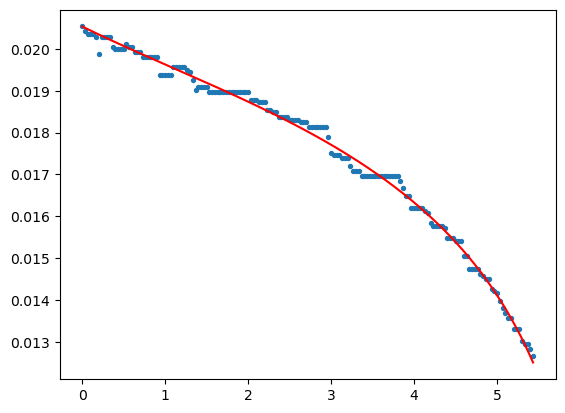

In [29]:
t_data,y_data=np.array(t_data_),np.array(y_data_)
plt.scatter(t_data,y_data,s=8)
Lc=2.7*10**(-3)
def cheerios_true(t_data,A,B,v0):
    dt=0.001
    t=np.arange(0,5.433333,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = 0.02053573, v0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
[[A,B,v0],_]=curve_fit(cheerios_true,t_data,y_data)

t,x=cheerios_true(None,A,B,v0)
plt.plot(t,x,'r')
print(v0)

Time shape: (165,)
X shape:    (165,)
Y shape:    (165,)


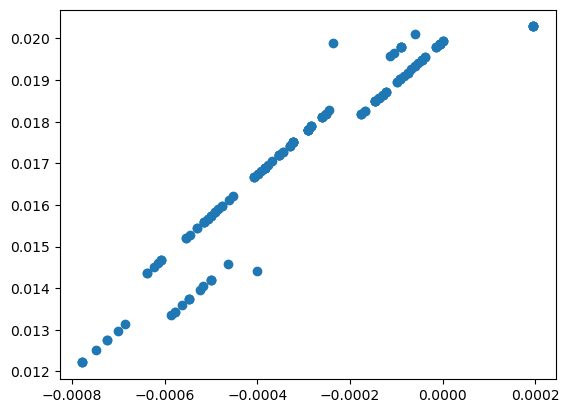

In [30]:
import numpy as np

# Dataset: massa_A spatial decay profile

# 1. Time values (t)
t_data = np.array([
    0.0, 0.03333333, 0.06666667, 0.1, 0.1333333, 0.1666667, 0.2, 0.2333333, 
    0.2666667, 0.3, 0.3333333, 0.3666667, 0.4, 0.4333333, 0.4666667, 0.5, 
    0.5333333, 0.5666667, 0.6, 0.6333333, 0.6666667, 0.7, 0.7333333, 0.7666667, 
    0.8, 0.8333333, 0.8666667, 0.9, 0.9333333, 0.9666667, 1.0, 1.033333, 
    1.066667, 1.1, 1.133333, 1.166667, 1.2, 1.233333, 1.266667, 1.3, 
    1.333333, 1.366667, 1.4, 1.433333, 1.466667, 1.5, 1.533333, 1.566667, 
    1.6, 1.633333, 1.666667, 1.7, 1.733333, 1.766667, 1.8, 1.833333, 
    1.866667, 1.9, 1.933333, 1.966667, 2.0, 2.033333, 2.066667, 2.1, 
    2.133333, 2.166667, 2.2, 2.233333, 2.266667, 2.3, 2.333333, 2.366667, 
    2.4, 2.433333, 2.466667, 2.5, 2.533333, 2.566667, 2.6, 2.633333, 
    2.666667, 2.7, 2.733333, 2.766667, 2.8, 2.833333, 2.866667, 2.9, 
    2.933333, 2.966667, 3.0, 3.033333, 3.066667, 3.1, 3.133333, 3.166667, 
    3.2, 3.233333, 3.266667, 3.3, 3.333333, 3.366667, 3.4, 3.433333, 
    3.466667, 3.5, 3.533333, 3.566667, 3.6, 3.633333, 3.666667, 3.7, 
    3.733333, 3.766667, 3.8, 3.833333, 3.866667, 3.9, 3.933333, 3.966667, 
    4.0, 4.033333, 4.066667, 4.1, 4.133333, 4.166667, 4.2, 4.233333, 
    4.266667, 4.3, 4.333333, 4.366667, 4.4, 4.433333, 4.466667, 4.5, 
    4.533333, 4.566667, 4.6, 4.633333, 4.666667, 4.7, 4.733333, 4.766667, 
    4.8, 4.833333, 4.866667, 4.9, 4.933333, 4.966667, 5.0, 5.033333, 
    5.066667, 5.1, 5.133333, 5.166667, 5.2, 5.233333, 5.266667, 5.3, 
    5.333333, 5.366667, 5.4, 5.433333, 5.466667
])

# 2. Coordinate values (x)
x_data = np.array([
    0.0001948898, 0.0001948898, 0.0001948898, 0.0001948898, 0.0001948898, 
    -6.431507e-06, 1.286301e-06, 1.286301e-06, 1.286301e-06, -6.431507e-06, 
    -6.431507e-06, -6.431507e-06, -6.431507e-06, -6.431507e-06, -6.431507e-06, 
    -1.414931e-05, -1.414931e-05, -0.0001061199, -0.0001138377, -5.981301e-05, 
    -9.068424e-05, -9.068424e-05, -9.068424e-05, -1.414931e-05, -0.0002360363, 
    -9.068424e-05, -3.730274e-05, -3.730274e-05, -4.502055e-05, -4.502055e-05, 
    -4.502055e-05, -4.502055e-05, -5.273835e-05, -6.045616e-05, -6.045616e-05, 
    -6.817397e-05, -7.589178e-05, -7.589178e-05, -7.589178e-05, -8.360959e-05, 
    -9.132739e-05, -9.132739e-05, -9.132739e-05, -9.132739e-05, -9.90452e-05, 
    -9.90452e-05, -0.0001221986, -0.0001221986, -0.0001221986, -0.0001299164, 
    -0.0001299164, -0.0001299164, -0.0001376342, -0.0001376342, -0.0001376342, 
    -0.000145352, -0.000145352, -0.000145352, -0.000145352, -0.000145352, 
    -0.0001685055, -0.0001685055, -0.0001762233, -0.0001762233, -0.0001762233, 
    -0.0002450404, -0.0002527582, -0.0002527582, -0.0002527582, -0.000260476, 
    -0.000260476, -0.000260476, -0.000260476, -0.0002836294, -0.0002836294, 
    -0.0002836294, -0.0002836294, -0.0002913472, -0.0002913472, -0.0002913472, 
    -0.0002913472, -0.0002913472, -0.0002913472, -0.0002913472, -0.0003222185, 
    -0.0003222185, -0.0003222185, -0.0003222185, -0.0003222185, -0.0003222185, 
    -0.0003299363, -0.0003299363, -0.0003299363, -0.0003453719, -0.0003453719, 
    -0.0003530897, -0.0003530897, -0.0003530897, -0.0003530897, -0.0003530897, 
    -0.0003685253, -0.0003762431, -0.0003839609, -0.0003839609, -0.0003839609, 
    -0.0003839609, -0.0003839609, -0.0003839609, -0.0003839609, -0.0003916787, 
    -0.0003993966, -0.0003993966, -0.0004071144, -0.0004071144, -0.0004071144, 
    -0.0004534212, -0.000461139, -0.0004765746, -0.0004765746, -0.0004842924, 
    -0.0005151637, -0.0005151637, -0.0004920103, -0.0004997281, -0.0004997281, 
    -0.0005074459, -0.0004920103, -0.0004997281, -0.0005074459, -0.0005151637, 
    -0.0005151637, -0.0005305993, -0.0005305993, -0.0005460349, -0.0005537527, 
    -0.0005537527, -0.0006154952, -0.0006077774, -0.0006077774, -0.0006077774, 
    -0.000623213, -0.0006386486, -0.0006386486, -0.0004624253, -0.000401326, 
    -0.0005010144, -0.0005010144, -0.0005010144, -0.00051645, -0.0005241678, 
    -0.0005473212, -0.0005473212, -0.0005473212, -0.0005627568, -0.0005781924, 
    -0.0005781924, -0.0005859102, -0.0006855986, -0.0007010342, -0.0007241876, 
    -0.0007241876, -0.0007473411, -0.0007782123, -0.0007782123, -0.0007782123,
])

# 3. Variable values (y)
y_data = np.array([
    0.02028825, 0.02028825, 0.02028825, 0.02028825, 0.02028825, 0.01987014, 
    0.01994667, 0.01994667, 0.01994667, 0.01987014, 0.01987014, 0.01987014, 
    0.01987014, 0.01987014, 0.01987014, 0.0197936, 0.0197936, 0.01964825, 
    0.01957172, 0.02010746, 0.01980132, 0.01980132, 0.01980132, 0.0197936, 
    0.01989329, 0.01980132, 0.019564, 0.019564, 0.01948746, 0.01948746, 
    0.01948746, 0.01948746, 0.01941093, 0.0193344, 0.0193344, 0.01925786, 
    0.01918133, 0.01918133, 0.01918133, 0.01910479, 0.01902826, 0.01902826, 
    0.01902826, 0.01902826, 0.01895172, 0.01895172, 0.01872212, 0.01872212, 
    0.01872212, 0.01864558, 0.01864558, 0.01864558, 0.01856905, 0.01856905, 
    0.01856905, 0.01849251, 0.01849251, 0.01849251, 0.01849251, 0.01849251, 
    0.01826291, 0.01826291, 0.01818637, 0.01818637, 0.01818637, 0.01827062, 
    0.01819409, 0.01819409, 0.01819409, 0.01811755, 0.01811755, 0.01811755, 
    0.01811755, 0.01788795, 0.01788795, 0.01788795, 0.01788795, 0.01781141, 
    0.01781141, 0.01781141, 0.01781141, 0.01781141, 0.01781141, 0.01781141, 
    0.01750527, 0.01750527, 0.01750527, 0.01750527, 0.01750527, 0.01750527, 
    0.01742874, 0.01742874, 0.01742874, 0.01727567, 0.01727567, 0.01719913, 
    0.01719913, 0.01719913, 0.01719913, 0.01719913, 0.01704606, 0.01696953, 
    0.016893, 0.016893, 0.016893, 0.016893, 0.016893, 0.016893, 
    0.016893, 0.01681646, 0.01673993, 0.01673993, 0.01666339, 0.01666339, 
    0.01666339, 0.01620418, 0.01612765, 0.01597458, 0.01597458, 0.01589804, 
    0.0155919, 0.0155919, 0.01582151, 0.01574497, 0.01574497, 0.01566844, 
    0.01582151, 0.01574497, 0.01566844, 0.0155919, 0.0155919, 0.01543883, 
    0.01543883, 0.01528576, 0.01520923, 0.01520923, 0.01459695, 0.01467348, 
    0.01467348, 0.01467348, 0.01452041, 0.01436734, 0.01436734, 0.01458151, 
    0.01442072, 0.01419884, 0.01419884, 0.01419884, 0.01404577, 0.01396923, 
    0.01373963, 0.01373963, 0.01373963, 0.01358656, 0.01343349, 0.01343349, 
    0.01335695, 0.01313507, 0.012982, 0.01275239, 0.01275239, 0.01252279, 
    0.01221665, 0.01221665,0.01221665
])
print(f"Time shape: {t_data.shape}")
print(f"X shape:    {x_data.shape}")
print(f"Y shape:    {y_data.shape}")
plt.scatter(x_data,y_data)

0.44516012221562384 1.0237929637643703


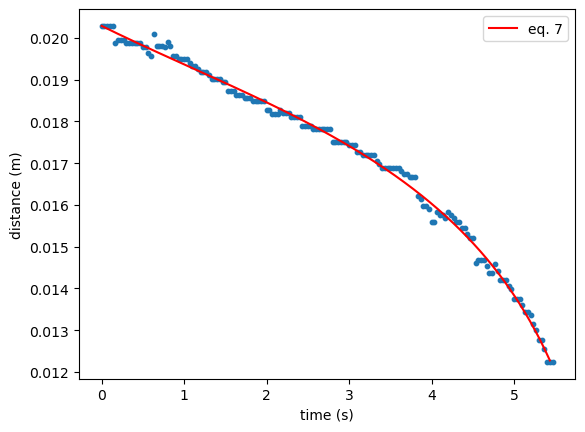

In [31]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import k1
r_data=np.sqrt(x_data**2+y_data**2)
plt.scatter(t_data,r_data,s=10)
Lc=2.7*10**(-3)
def cheerios_true(t_data,A,B,v0):
    dt=0.001
    t=np.arange(0,5.433333,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r_data[0], v0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
[[A,B,v0],_]=curve_fit(cheerios_true,t_data,r_data,p0=[0.3,0.3,0.1])
print(A,B)
t,x=cheerios_true(None,A,B,v0)
plt.plot(t,x,'r',label='eq. 7')
def cheerios_not_true(t_data,C,D):
    dt=0.001
    t=np.arange(0,5.433333,dt)
    x=np.zeros(len(t))
    x[0]=r_data[0]
    for i in range(len(t)-1):
        v=C*k1(x[i]/D)
        x[i+1]=x[i]+v*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
    
[[C,D],_]=curve_fit(cheerios_not_true,t_data,r_data)

t,x=cheerios_not_true(None,C,D)
#plt.plot(t,x,'g--',label='wrong model')

plt.legend()
plt.xlabel('time (s)')
plt.ylabel('distance (m)')

t_max = np.max(t_data)
r0_sq = r_data[0] ** 2
E_max = r0_sq / t_max

fun=lambda t,E: np.sqrt(r_data[0]**2-E*t)
[[E], pcov] = curve_fit(fun, t_data, r_data, p0=[E_max * 0.5], bounds=(0, E_max * 0.999))
#plt.plot(t,fun(t,E),'--',color='blue')

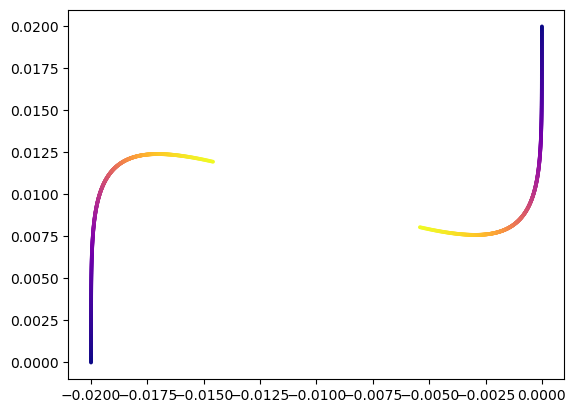

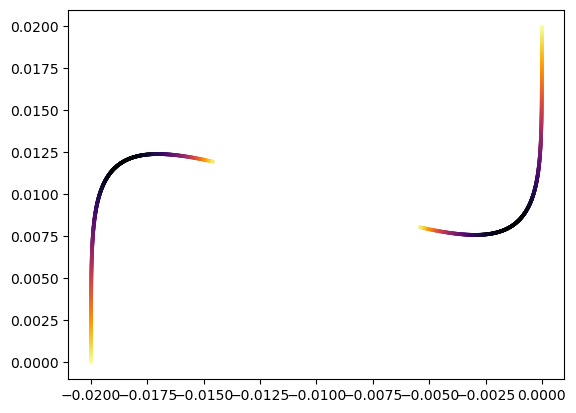

In [32]:
import numpy as np
from scipy.special import k1
import matplotlib.pyplot as plt
#        ini=[x1,    y1,x2,y2,vx1,vy1,vx2,vy2]
ini=np.array([-2, 0,  0, 2,  0, 0.6,   0, -0.6])*10**(-2)
A,B=0.44516012221562384,1.0237929637643703
Lc=2.7*10**(-3)
def cheerios_dynamics_duo(ini,A,B):
    dt=0.01
    t=np.arange(0,100,dt)
    x1=np.zeros(len(t))
    y1=np.zeros(len(t))
    x2=np.zeros(len(t))
    y2=np.zeros(len(t))
    vx1=np.zeros(len(t))
    vy1=np.zeros(len(t))
    vx2=np.zeros(len(t))
    vy2=np.zeros(len(t))
    x2[0],y2[0],vx2[0],vy2[0]=ini[2],ini[3],ini[6],ini[7]
    x1[0],y1[0],vx1[0],vy1[0]=ini[0],ini[1],ini[4],ini[5]
    end_indx=len(t)
    for i in range(len(t)-1):
        r=np.sqrt((x1[i]-x2[i])**2+(y1[i]-y2[i])**2)
        Attract=B*k1(r/Lc)
        

        
        ax2=-A*vx2[i]+Attract*(x1[i]-x2[i])/r
        ay2=-A*vy2[i]+Attract*(y1[i]-y2[i])/r
        ax1=-A*vx1[i]-Attract*(x1[i]-x2[i])/r
        ay1=-A*vy1[i]-Attract*(y1[i]-y2[i])/r
        vx2[i+1]=vx2[i]+ax2*dt
        vy2[i+1]=vy2[i]+ay2*dt
        vx1[i+1]=vx1[i]+ax1*dt
        vy1[i+1]=vy1[i]+ay1*dt 
        x2[i+1]=x2[i]+vx2[i]*dt
        y2[i+1]=y2[i]+vy2[i]*dt
        x1[i+1]=x1[i]+vx1[i]*dt
        y1[i+1]=y1[i]+vy1[i]*dt
        if r<0.01:
            end_indx=i+1
            break
    v1=np.sqrt(vx1**2+vy1**2)
    v2=np.sqrt(vx2**2+vy2**2)
    return t[:end_indx],x1[:end_indx],y1[:end_indx],x2[:end_indx],y2[:end_indx],v1[:end_indx],v2[:end_indx]

plt.close('all')
t,x1,y1,x2,y2,v1,v2=cheerios_dynamics_duo(ini,A,B)
sc1 = plt.scatter(x1, y1, c=t, cmap='plasma', s=3, label="Particle 1 Path")
sc2 = plt.scatter(x2, y2, c=t, cmap='plasma', s=3, label="Particle 2 Path")
plt.show()
sc3 = plt.scatter(x1, y1, c=v1, cmap='inferno', s=3, label="Particle 1 Path")
sc4 = plt.scatter(x2, y2, c=v2, cmap='inferno', s=3, label="Particle 2 Path")
plt.show()

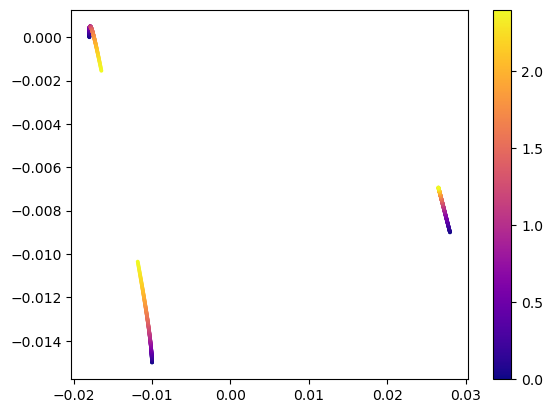

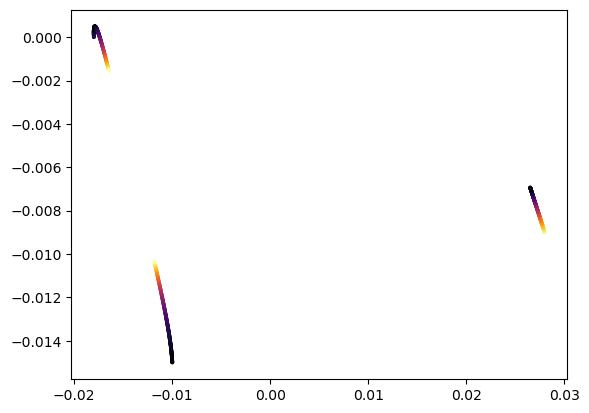

In [3]:
import numpy as np
from scipy.special import k1
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
#        ini=[x1,    y1,x2,y2,vx1,vy1,vx2,vy2]

x1,y1=-1.8,0
x2,y2=2.8,-0.9
x3,y3=-1,-1.5
vx1,vy1= -.01,0.11
vx2,vy2=-0.1,0.14
vx3,vy3=-0.01,0.1

ini=np.array([x1, y1,  x2, y2,  vx1, vy1,   vx2, vy2,x3,y3,vx3,vy3])*10**(-2)
A,B=0.44516012221562384,1.0237929637643703
Lc=2.7*10**(-3)
def three_cheerio_problem(ini,A,B):
    dt=0.01
    t=np.arange(0,100,dt)
    x1=np.zeros(len(t))
    y1=np.zeros(len(t))
    x2=np.zeros(len(t))
    y2=np.zeros(len(t))
    x3=np.zeros(len(t))
    y3=np.zeros(len(t))
    vx1=np.zeros(len(t))
    vy1=np.zeros(len(t))
    vx2=np.zeros(len(t))
    vy2=np.zeros(len(t))
    vx3=np.zeros(len(t))
    vy3=np.zeros(len(t))
    x2[0],y2[0],vx2[0],vy2[0]=ini[2],ini[3],ini[6],ini[7]
    x1[0],y1[0],vx1[0],vy1[0]=ini[0],ini[1],ini[4],ini[5]
    x3[0],y3[0],vx3[0],vy3[0]=ini[8],ini[9],ini[10],ini[11]
    end_indx=len(t)
    for i in range(len(t)-1):
        r12=np.sqrt((x1[i]-x2[i])**2+(y1[i]-y2[i])**2)
        r23=np.sqrt((x3[i]-x2[i])**2+(y3[i]-y2[i])**2)
        r13=np.sqrt((x3[i]-x1[i])**2+(y3[i]-y1[i])**2)
        Attract12=B*k1(r12/Lc)
        Attract23=B*k1(r23/Lc)
        Attract13=B*k1(r13/Lc)
        

        
        ax2=-A*vx2[i]+Attract12*(x1[i]-x2[i])/r12+Attract23*(x3[i]-x2[i])/r23
        ay2=-A*vy2[i]+Attract12*(y1[i]-y2[i])/r12+Attract23*(y3[i]-y2[i])/r23
        ax1=-A*vx1[i]-Attract12*(x1[i]-x2[i])/r12+Attract13*(x3[i]-x1[i])/r13
        ay1=-A*vy1[i]-Attract12*(y1[i]-y2[i])/r12+Attract13*(y3[i]-y1[i])/r13
        ax3=-A*vx3[i]-Attract23*(x3[i]-x2[i])/r23-Attract13*(x3[i]-x1[i])/r13
        ay3=-A*vy3[i]-Attract23*(y3[i]-y2[i])/r23-Attract13*(y3[i]-y1[i])/r13
        vx2[i+1]=vx2[i]+ax2*dt
        vy2[i+1]=vy2[i]+ay2*dt
        vx1[i+1]=vx1[i]+ax1*dt
        vy1[i+1]=vy1[i]+ay1*dt
        vx3[i+1]=vx3[i]+ax3*dt
        vy3[i+1]=vy3[i]+ay3*dt
        x2[i+1]=x2[i]+vx2[i]*dt
        y2[i+1]=y2[i]+vy2[i]*dt
        x1[i+1]=x1[i]+vx1[i]*dt
        y1[i+1]=y1[i]+vy1[i]*dt
        x3[i+1]=x3[i]+vx3[i]*dt
        y3[i+1]=y3[i]+vy3[i]*dt
        if r12<0.01:
            end_indx=i+1
            break
        elif r13<0.01:
            end_indx=i+1
            break
        elif r23<0.01:
            end_indx=i+1
            break
    v1=np.sqrt(vx1**2+vy1**2)
    v2=np.sqrt(vx2**2+vy2**2)
    v3=np.sqrt(vx3**2+vy3**2)
    return t[:end_indx],x1[:end_indx],y1[:end_indx],x2[:end_indx],y2[:end_indx],x3[:end_indx],y3[:end_indx],v1[:end_indx],v2[:end_indx],v3[:end_indx]

plt.close('all')
t,x1,y1,x2,y2,x3,y3,v1,v2,v3=three_cheerio_problem(ini,A,B)
sc1 = plt.scatter(x1, y1, c=t, cmap='plasma', s=3, label="Particle 1 Path")
sc2 = plt.scatter(x2, y2, c=t, cmap='plasma', s=3, label="Particle 2 Path")
sc3 = plt.scatter(x3, y3, c=t, cmap='plasma', s=3, label="Particle 3 Path")
plt.colorbar(sc1)
plt.show()
sc4 = plt.scatter(x1, y1, c=v1, cmap='inferno', s=3, label="Particle 1 Path")
sc5 = plt.scatter(x2, y2, c=v2, cmap='inferno', s=3, label="Particle 2 Path")
sc6 = plt.scatter(x3, y3, c=v3, cmap='inferno', s=3, label="Particle 3 Path")
plt.show()

In [34]:
p=4
test=[r1,r2,r3,r4,r5,r6,r7,r8,r9]
r=np.mean(test,axis=0)[:-28]
std=np.std(test,axis=0)[:-28]
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
plt.scatter(t,r1[:-28],s=p)
plt.scatter(t,r2[:-28],s=p)
plt.scatter(t,r3[:-28],s=p)
plt.scatter(t,r4[:-28],s=p)
plt.scatter(t,r5[:-28],s=p)
plt.scatter(t,r6[:-28],s=p)
plt.scatter(t,r7[:-28],s=p)
plt.scatter(t,r8[:-28],s=p)
plt.scatter(t,r9[:-28],s=p)
def cheerios_true(t_data,A,B,v0):
    dt=0.001
    t=np.arange(0,5.433333,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], v0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
[[A,B,v0],_]=curve_fit(cheerios_true,t,r,p0=[0.4455919554299826, 0.9908160534805467, -0.0006330372501584517])
print(A,B,v0)
t1,x1=cheerios_true(None,A,B,v0)
plt.plot(t1,x1,'r',label='eq. 7')

NameError: name 'r1' is not defined

In [38]:
import numpy as np

# Columns: t, x, y
t = np.array([0.000000e0, 3.333333e-2, 6.666667e-2, 1.000000e-1, 1.333333e-1, 1.666667e-1, 2.000000e-1, 2.333333e-1, 2.666667e-1, 3.000000e-1, 3.333333e-1, 3.666667e-1, 4.000000e-1, 4.333333e-1, 4.666667e-1, 5.000000e-1, 5.333333e-1, 5.666667e-1, 6.000000e-1, 6.333333e-1, 6.666667e-1, 7.000000e-1, 7.333333e-1, 7.666667e-1, 8.000000e-1, 8.333333e-1, 8.666667e-1, 9.000000e-1, 9.333333e-1, 9.666667e-1, 1.000000e0, 1.033333e0, 1.066667e0, 1.100000e0, 1.133333e0, 1.166667e0, 1.200000e0, 1.233333e0, 1.266667e0, 1.300000e0, 1.333333e0, 1.366667e0, 1.400000e0, 1.433333e0, 1.466667e0, 1.500000e0, 1.533333e0, 1.566667e0, 1.600000e0, 1.633333e0, 1.666667e0, 1.700000e0, 1.733333e0, 1.766667e0, 1.800000e0, 1.833333e0, 1.866667e0, 1.900000e0, 1.933333e0, 1.966667e0, 2.000000e0, 2.033333e0, 2.066667e0, 2.100000e0, 2.133333e0, 2.166667e0, 2.200000e0, 2.233333e0, 2.266667e0, 2.300000e0, 2.333333e0, 2.366667e0, 2.400000e0, 2.433333e0, 2.466667e0, 2.500000e0, 2.533333e0, 2.566667e0, 2.600000e0, 2.633333e0, 2.666667e0, 2.700000e0, 2.733333e0, 2.766667e0, 2.800000e0, 2.833333e0, 2.866667e0, 2.900000e0, 2.933333e0, 2.966667e0, 3.000000e0, 3.033333e0, 3.066667e0, 3.100000e0, 3.133333e0, 3.166667e0, 3.200000e0, 3.233333e0, 3.266667e0, 3.300000e0, 3.333333e0, 3.366667e0, 3.400000e0, 3.433333e0, 3.466667e0, 3.500000e0, 3.533333e0, 3.566667e0, 3.600000e0, 3.633333e0, 3.666667e0, 3.700000e0, 3.733333e0, 3.766667e0, 3.800000e0, 3.833333e0, 3.866667e0, 3.900000e0, 3.933333e0, 3.966667e0, 4.000000e0, 4.033333e0, 4.066667e0, 4.100000e0, 4.133333e0, 4.166667e0, 4.200000e0, 4.233333e0, 4.266667e0, 4.300000e0, 4.333333e0, 4.366667e0, 4.400000e0, 4.433333e0, 4.466667e0, 4.500000e0, 4.533333e0, 4.566667e0, 4.600000e0, 4.633333e0, 4.666667e0, 4.700000e0, 4.733333e0, 4.766667e0, 4.800000e0, 4.833333e0, 4.866667e0, 4.900000e0, 4.933333e0, 4.966667e0, 5.000000e0, 5.033333e0, 5.066667e0, 5.100000e0, 5.133333e0, 5.166667e0, 5.200000e0, 5.233333e0, 5.266667e0, 5.300000e0, 5.333333e0, 5.366667e0, 5.400000e0, 5.433333e0, 5.466667e0, 5.500000e0, 5.533333e0, 5.566667e0, 5.600000e0, 5.633333e0, 5.666667e0, 5.700000e0, 5.733333e0, 5.766667e0])

x = np.array([1.041642e-4, 1.312020e-4, 1.047639e-4, 1.055721e-4, 1.054571e-4, 9.156904e-5, 1.210310e-4, 9.795856e-5, 9.574125e-5, 6.006747e-5, 6.124846e-5, 6.269906e-5, 5.505928e-5, 6.333332e-5, 6.143463e-5, 5.973066e-5, 5.918306e-5, 5.929841e-5, 2.720178e-5, 2.600431e-5, 2.673787e-5, 2.667843e-5, 2.906267e-5, 2.879400e-5, 2.753874e-5, 2.714587e-5, 4.156841e-5, 4.435535e-5, 3.319171e-5, 3.550407e-5, 4.941348e-5, 4.642523e-5, 4.467545e-5, 4.397571e-5, 4.355448e-5, 2.951911e-5, 2.792553e-5, 3.016990e-5, 1.959673e-5, 2.075757e-5, 2.502249e-5, 2.536840e-5, 2.182573e-5, 2.382618e-5, 1.468605e-5, 1.593526e-5, 1.031517e-5, 1.266674e-5, 1.301727e-6, 2.343729e-6, 2.570775e-6, 3.134326e-6, 2.921486e-6, 3.035783e-6, -9.763931e-6, -8.596483e-6, 1.995059e-6, -1.366129e-5, -1.418467e-5, -2.012114e-5, -8.664498e-5, -8.646186e-5, -8.618974e-5, -7.817727e-5, -8.289577e-5, -8.254046e-5, -8.599998e-5, -8.570515e-5, -8.786903e-5, -9.413369e-5, -1.091446e-4, -1.065303e-4, -1.130114e-4, -1.147652e-4, -1.188055e-4, -7.137433e-5, -7.250159e-5, -7.315853e-5, -8.020384e-5, -8.337458e-5, -8.305558e-5, -8.599957e-5, -9.335535e-5, -9.147658e-5, -8.995001e-5, -8.762648e-5, -9.562031e-5, -9.511555e-5, -1.101624e-4, -1.111951e-4, -1.500641e-4, -1.523464e-4, -1.556522e-4, -1.609591e-4, -1.629621e-4, -1.636048e-4, -1.712578e-4, -1.707585e-4, -1.714825e-4, -1.762555e-4, -1.817079e-4, -1.732729e-4, -1.737630e-4, -1.729049e-4, -1.744410e-4, -1.855245e-4, -1.911368e-4, -1.935028e-4, -1.922911e-4, -1.924178e-4, -1.940603e-4, -1.954696e-4, -2.011775e-4, -2.077268e-4, -1.859666e-4, -1.901731e-4, -1.923252e-4, -2.020721e-4, -2.061374e-4, -2.129041e-4, -1.855050e-4, -1.883939e-4, -1.955334e-4, -1.891387e-4, -2.068156e-4, -2.083103e-4, -2.132000e-4, -2.284238e-4, -2.367705e-4, -2.354828e-4, -2.372225e-4, -2.359945e-4, -2.360730e-4, -2.486958e-4, -2.605031e-4, -2.683745e-4, -2.688703e-4, -2.829796e-4, -2.785699e-4, -2.866899e-4, -2.769962e-4, -2.860832e-4, -2.975545e-4, -3.028018e-4, -3.034238e-4, -3.051960e-4, -3.054317e-4, -3.169664e-4, -3.277462e-4, -3.395538e-4, -3.560354e-4, -3.655357e-4, -3.656193e-4, -3.806524e-4, -3.871001e-4, -3.961111e-4, -3.991946e-4, -4.103288e-4, -4.192551e-4, -4.463814e-4, -4.497877e-4, -4.659937e-4, -4.439243e-4, -4.613764e-4, -4.620881e-4, -4.685149e-4, -4.828378e-4, -5.125415e-4, -5.146460e-4, -5.148068e-4, -5.263159e-4, -5.462926e-4, -5.559449e-4, -5.718124e-4])

y = np.array([1.927527e-2, 1.926919e-2, 1.928377e-2, 1.927236e-2, 1.927327e-2, 1.914796e-2, 1.914308e-2, 1.914804e-2, 1.914769e-2, 1.902309e-2, 1.902277e-2, 1.902054e-2, 1.902557e-2, 1.902135e-2, 1.901525e-2, 1.900823e-2, 1.900484e-2, 1.900430e-2, 1.883111e-2, 1.883837e-2, 1.883822e-2, 1.883784e-2, 1.883304e-2, 1.883455e-2, 1.883531e-2, 1.883550e-2, 1.883477e-2, 1.861697e-2, 1.848574e-2, 1.848646e-2, 1.849370e-2, 1.849212e-2, 1.849101e-2, 1.849013e-2, 1.849013e-2, 1.849007e-2, 1.839873e-2, 1.839986e-2, 1.828350e-2, 1.828129e-2, 1.827573e-2, 1.827638e-2, 1.832543e-2, 1.832154e-2, 1.821468e-2, 1.821397e-2, 1.821324e-2, 1.821309e-2, 1.806783e-2, 1.806667e-2, 1.806574e-2, 1.806503e-2, 1.805847e-2, 1.806022e-2, 1.795907e-2, 1.795629e-2, 1.789891e-2, 1.781249e-2, 1.780644e-2, 1.773716e-2, 1.771044e-2, 1.770847e-2, 1.770939e-2, 1.770871e-2, 1.765549e-2, 1.764661e-2, 1.764761e-2, 1.764746e-2, 1.752083e-2, 1.750273e-2, 1.750655e-2, 1.750318e-2, 1.743411e-2, 1.736525e-2, 1.734881e-2, 1.731932e-2, 1.731830e-2, 1.732101e-2, 1.725722e-2, 1.724926e-2, 1.724438e-2, 1.718293e-2, 1.709230e-2, 1.707880e-2, 1.704766e-2, 1.704121e-2, 1.702162e-2, 1.695307e-2, 1.680065e-2, 1.679671e-2, 1.678165e-2, 1.676722e-2, 1.671737e-2, 1.669727e-2, 1.666383e-2, 1.666569e-2, 1.659119e-2, 1.656886e-2, 1.654556e-2, 1.650892e-2, 1.644546e-2, 1.639154e-2, 1.635485e-2, 1.630352e-2, 1.629386e-2, 1.620501e-2, 1.619693e-2, 1.615187e-2, 1.614483e-2, 1.611541e-2, 1.606922e-2, 1.606008e-2, 1.602095e-2, 1.601283e-2, 1.587724e-2, 1.579001e-2, 1.578289e-2, 1.572719e-2, 1.566705e-2, 1.556175e-2, 1.555118e-2, 1.555059e-2, 1.551782e-2, 1.548781e-2, 1.533581e-2, 1.532229e-2, 1.526587e-2, 1.517038e-2, 1.507764e-2, 1.506581e-2, 1.504348e-2, 1.498512e-2, 1.494568e-2, 1.480472e-2, 1.464962e-2, 1.462966e-2, 1.458049e-2, 1.448625e-2, 1.448141e-2, 1.438105e-2, 1.428497e-2, 1.423803e-2, 1.412452e-2, 1.409725e-2, 1.400349e-2, 1.393369e-2, 1.385919e-2, 1.381497e-2, 1.367536e-2, 1.354534e-2, 1.349184e-2, 1.339284e-2, 1.330937e-2, 1.315534e-2, 1.303377e-2, 1.296426e-2, 1.287310e-2, 1.272131e-2, 1.258729e-2, 1.249614e-2, 1.238879e-2, 1.214534e-2, 1.203384e-2, 1.197692e-2, 1.198745e-2, 1.194417e-2, 1.184872e-2, 1.184444e-2, 1.184174e-2, 1.172193e-2, 1.172018e-2, 1.157642e-2, 1.157911e-2, 1.151099e-2])
t=t[:-10]
r=np.sqrt(x**2+y**2)[:-10]
      

0.6031983358926429 0.9552568281253755 -0.0007179313840171737


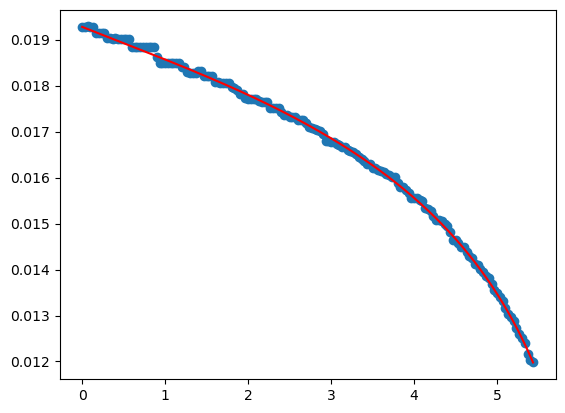

In [39]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import k1
Lc=2.7*10**(-3)
def cheerios_true(t_data,A,B,v0):
    dt=0.001
    t=np.arange(0,5.433333,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], v0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
[[A,B,v0],_]=curve_fit(cheerios_true,t,r,p0=[0.4455919554299826, 0.9908160534805467, -0.0006330372501584517])
print(A,B,v0)
plt.scatter(t,r)
t1,x1=cheerios_true(None,A,B,v0)
plt.plot(t1,x1,'r',label='eq. 7')


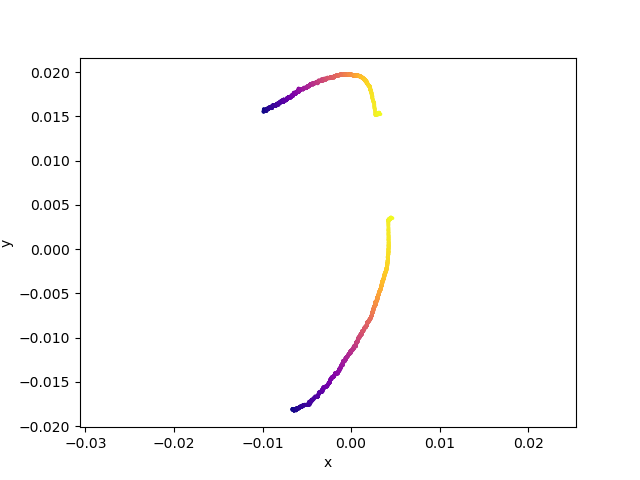

In [88]:
import numpy as np
matrix = np.loadtxt(
    'data 1.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)


t1 = matrix[:, 0]
x1 = matrix[:, 1]
y1 = matrix[:, 2]

plt.close('all')
sc1 = plt.scatter(x1, y1, c=t1, cmap='plasma', s=3, label="Particle 1 Path")
matrix = np.loadtxt(
    'data 2.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)
t2 = matrix[:, 0]
x2 = matrix[:, 1]
y2 = matrix[:, 2]
sc2 = plt.scatter(x2, y2, c=t2, cmap='plasma', s=3, label="Particle 2 Path")
plt.ylabel('y')
plt.xlabel('x')
plt.axis('equal')
plt.show()

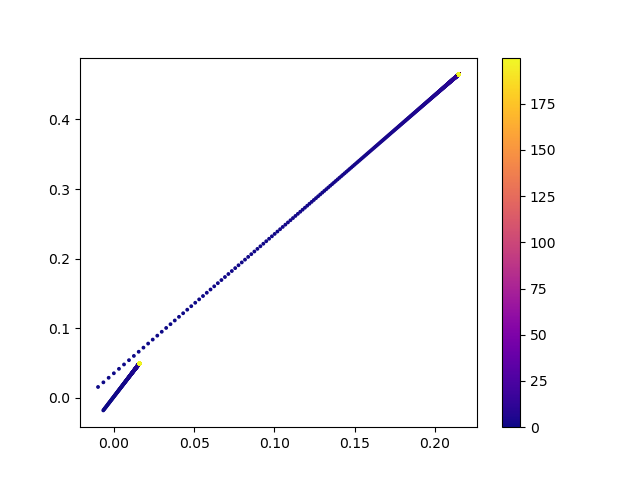

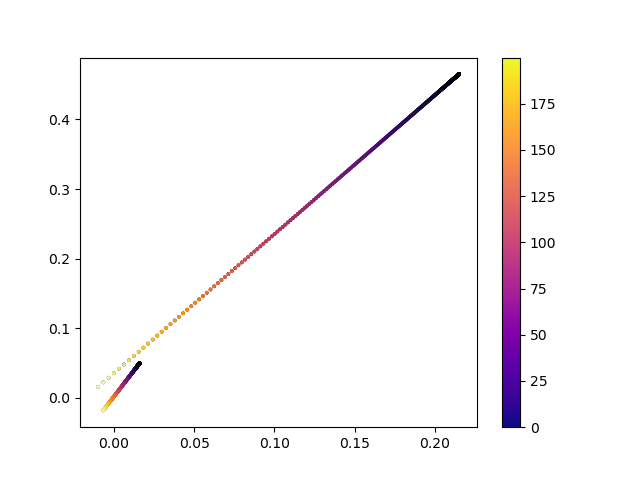

In [87]:
import numpy as np
from scipy.special import k1
import matplotlib.pyplot as plt
#        ini=[x1,    y1,x2,y2,vx1,vy1,vx2,vy2]
ini=np.array([x1[0], y1[0],  x2[0], y2[0],  0.01, 0.03,   0.1,0.2] )
A,B=0.44516012221562384,1.0237929637643703
Lc=2.7*10**(-3)
def cheerios_dynamics_duo(ini,A,B):
    dt=1/30
    t=np.arange(0,200,dt)
    x1=np.zeros(len(t))
    y1=np.zeros(len(t))
    x2=np.zeros(len(t))
    y2=np.zeros(len(t))
    vx1=np.zeros(len(t))
    vy1=np.zeros(len(t))
    vx2=np.zeros(len(t))
    vy2=np.zeros(len(t))
    x2[0],y2[0],vx2[0],vy2[0]=ini[2],ini[3],ini[6],ini[7]
    x1[0],y1[0],vx1[0],vy1[0]=ini[0],ini[1],ini[4],ini[5]
    end_indx=len(t)
    for i in range(len(t)-1):
        r=np.sqrt((x1[i]-x2[i])**2+(y1[i]-y2[i])**2)
        Attract=B*k1(r/Lc)
        

        
        ax2=-A*vx2[i]+Attract*(x1[i]-x2[i])/r
        ay2=-A*vy2[i]+Attract*(y1[i]-y2[i])/r
        ax1=-A*vx1[i]-Attract*(x1[i]-x2[i])/r
        ay1=-A*vy1[i]-Attract*(y1[i]-y2[i])/r
        vx2[i+1]=vx2[i]+ax2*dt
        vy2[i+1]=vy2[i]+ay2*dt
        vx1[i+1]=vx1[i]+ax1*dt
        vy1[i+1]=vy1[i]+ay1*dt 
        x2[i+1]=x2[i]+vx2[i]*dt
        y2[i+1]=y2[i]+vy2[i]*dt
        x1[i+1]=x1[i]+vx1[i]*dt
        y1[i+1]=y1[i]+vy1[i]*dt
        if r<0.01:
            end_indx=i+1
            break
    v1=np.sqrt(vx1**2+vy1**2)
    v2=np.sqrt(vx2**2+vy2**2)
    return t[:end_indx],x1[:end_indx],y1[:end_indx],x2[:end_indx],y2[:end_indx],v1[:end_indx],v2[:end_indx]

plt.close('all')
t,x1,y1,x2,y2,v1,v2=cheerios_dynamics_duo(ini,A,B)
sc1 = plt.scatter(x1, y1, c=t, cmap='plasma', s=3, label="Particle 1 Path")
sc2 = plt.scatter(x2, y2, c=t, cmap='plasma', s=3, label="Particle 2 Path")
plt.colorbar(sc1)
plt.show()
sc3 = plt.scatter(x1, y1, c=v1, cmap='inferno', s=3, label="Particle 1 Path")
sc4 = plt.scatter(x2, y2, c=v2, cmap='inferno', s=3, label="Particle 2 Path")
plt.show()

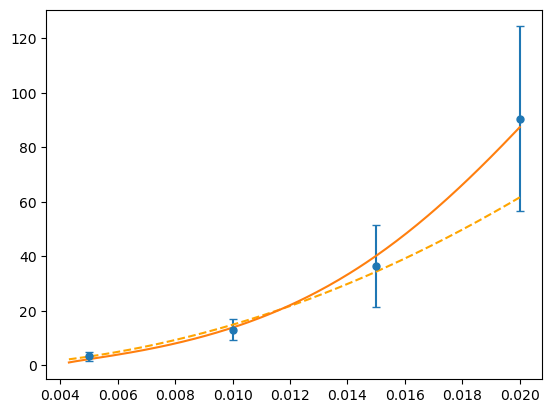

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import k1
from scipy.optimize import curve_fit
distances=np.array([5,10,15,20])*10**(-3) ##m
contact_time=np.array([3.312,13.078,36.422,90.368])
stdev=np.array([1.648156546,3.834647311,15.04428862,33.90639423])
r=0.001
plt.close('all')
plt.errorbar(distances,contact_time,stdev,fmt='o',markersize=5,capsize=3)
fun=lambda x,A:A*(x**2-4*(r)**2)
[A],_=curve_fit(fun,distances,contact_time,sigma=stdev)
x=np.linspace(0.0043,distances[-1],1000)
plt.plot(x,fun(x,A),'--',color='orange')
Lc=2.7*10**(-3)
def cheerios_true(x,A,B):
    t=np.zeros(len(x))
    for j in range(len(x)):
        
        dt=0.001
        t_sim=np.arange(0,120,dt)
        x_sim=np.zeros(len(t_sim))
        v_sim=np.zeros(len(t_sim))
        x_sim[0], v_sim[0] = x[j], 0
        for i in range(len(t_sim)-1):
            if x[j]<0.004:
                t[j]=0
                break
            a=-A*v_sim[i]-B*k1(x_sim[i]/Lc)
            v_sim[i+1]=v_sim[i]+a*dt
            x_sim[i+1]=x_sim[i]+v_sim[i]*dt
            if x_sim[i+1]<=0.004:
                t[j]=t_sim[i+1]
                break
    return t
def objective_loss(params):
    A, B = params
    t_pred = cheerios_true(distances, A, B)
    error = np.sum(((t_pred - contact_time) / stdev) ** 2)
    return error
initial_guess = [-0.04, 0.001]
result = minimize(objective_loss, initial_guess)
A,B=result.x

t=cheerios_true(x,A,B)
plt.plot(x,t)
plt.show()

In [6]:

print(A,B)

-0.04 0.001968841670544606


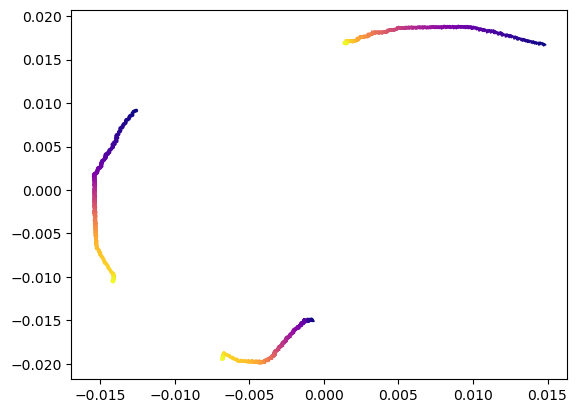

In [7]:
import numpy as np
import matplotlib.pyplot as plt
matrix = np.loadtxt(
    'data 3A.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)


t1 = matrix[:, 0]
x1 = matrix[:, 1]
y1 = matrix[:, 2]
matrix = np.loadtxt(
    'data 3B.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)


t2 = matrix[:, 0]
x2 = matrix[:, 1]
y2 = matrix[:, 2]

matrix = np.loadtxt(
    'data 3C.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)


t3 = matrix[:, 0]
x3 = matrix[:, 1]
y3 = matrix[:, 2]

plt.close('all')
sc1 = plt.scatter(x1, y1, c=t1, cmap='plasma',marker='o', s=3, label="Particle 1 Path")
sc2 = plt.scatter(x2, y2, c=t2, cmap='plasma', s=3,marker='^', label="Particle 2 Path")
sc3 = plt.scatter(x3, y3, c=t3, cmap='plasma', s=3, marker='>',label="Particle 3 Path")

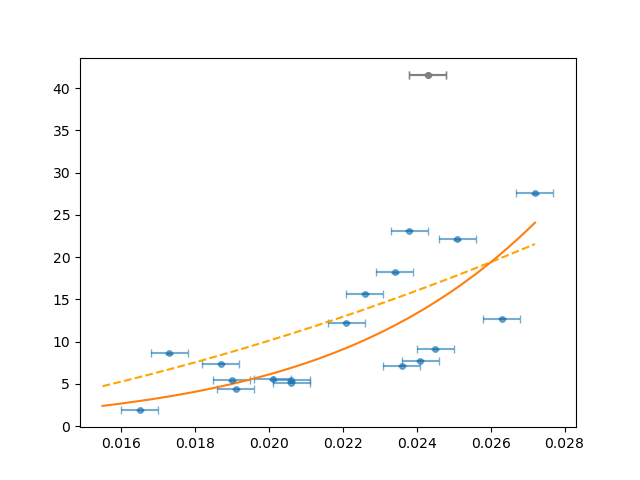

In [40]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
plt.close('all')
x=np.array([0.0263,0.0272,0.0173,0.0238,0.0243,0.0236,0.0187,0.0226,0.0241,0.0206,0.0165,0.0191,0.0221,0.0234,0.0201,0.0245,0.019,0.0251,0.0206])
t=np.array([12.73,27.53,8.6,23.13,41.57,7.16,7.4,15.67,7.73,5.16,1.9,4.4,12.23,18.2,5.53,9.13,5.4,22.1,5.4])
x_error=0.0005
t_error=0.04
plt.errorbar(x,t,xerr=x_error,yerr=t_error,fmt='o',alpha=0.6,zorder=2,ms=4,capsize=3)
plt.errorbar(0.0243,41.57,xerr=x_error,yerr=t_error,fmt='o',zorder=2,color='gray',ms=4,capsize=3)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import k1
from scipy.optimize import curve_fit
r=0.005
fun=lambda x,A:A*(x**2-4*(r)**2)
[A],_=curve_fit(fun,x,t,t_error)
x_plot=np.linspace(np.min(x)-0.001,np.max(x),1000)
plt.plot(x_plot,fun(x_plot,A),'--',color='orange')
Lc=2.7*10**(-3)
def cheerios_true(x,A,B):
    t=np.zeros(len(x))
    for j in range(len(x)):
        
        dt=0.001
        t_sim=np.arange(0,120,dt)
        x_sim=np.zeros(len(t_sim))
        v_sim=np.zeros(len(t_sim))
        x_sim[0], v_sim[0] = x[j], 0
        for i in range(len(t_sim)-1):
            if x[j]<0.004:
                t[j]=0
                break
            a=-A*v_sim[i]-B*k1(x_sim[i]/Lc)
            v_sim[i+1]=v_sim[i]+a*dt
            x_sim[i+1]=x_sim[i]+v_sim[i]*dt
            if x_sim[i+1]<=0.004:
                t[j]=t_sim[i+1]
                break
    return t
def error_cheerios(params):
    A,B=params
    t_sim=cheerios_true(x,A,B)
    error=np.sum(((t_sim-t)/t_error)**2)
    return error
initial_gues=[-0.04,0.001]
results=minimize(error_cheerios,initial_gues)
A,B=results.x
t_plot=cheerios_true(x_plot,A,B)
plt.plot(x_plot,t_plot)

2.6 9.0


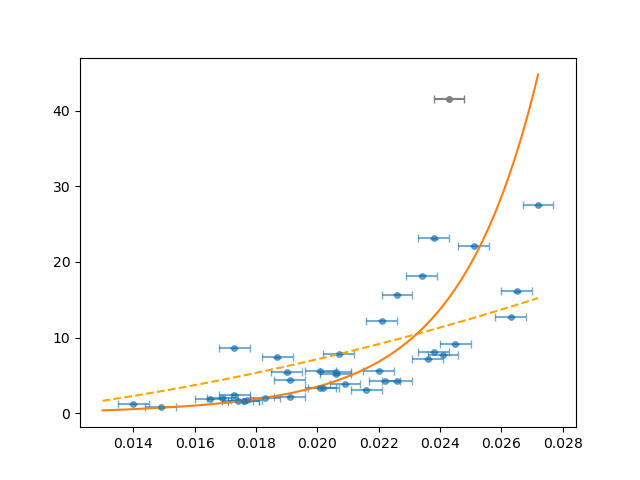

In [137]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget
plt.close('all')
x = np.array([
    0.0263, 0.0272, 0.0173, 0.0238, 0.0236, 0.0187, 0.0226, 0.0241, 0.0206, 0.0165,
    0.0191, 0.0221, 0.0234, 0.0201, 0.0245, 0.019,  0.0251, 0.0206, 0.0201, 0.0226,
    0.0202, 0.0238, 0.0173, 0.022,  0.0216, 0.0209, 0.014,  0.0183, 0.0207, 0.0265,
    0.0177, 0.0174, 0.0191, 0.0176, 0.0176, 0.0149, 0.0169, 0.0222
])

t = np.array([
    12.73,  27.53,  8.6,    23.13,  7.16,   7.4,    15.67,  7.73,   5.16,   1.9,
    4.4,    12.23,  18.2,   5.53,   9.13,   5.4,    22.1,   5.4,    3.37,   4.21,
    3.33,   8.07,   2.47,   5.63,   3.1,    3.867,  1.2,    2.0,    7.853,  16.118,
    1.7,    1.6,    2.2,    1.63,   1.6,    0.77,   2.0,    4.27
])

x_error=0.0005
t_error=0.04
plt.close('all')
plt.errorbar(x,t,xerr=x_error,yerr=t_error,fmt='o',alpha=0.6,zorder=2,ms=4,capsize=3)
plt.errorbar(0.0243,41.57,xerr=x_error,yerr=t_error,fmt='o',zorder=2,color='gray',ms=4,capsize=3)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import k1
from scipy.optimize import curve_fit
r=0.005
fun=lambda x,A:A*(x**2-4*(r)**2)
[A],_=curve_fit(fun,x,t,t_error)
x_plot=np.linspace(np.min(x)-0.001,np.max(x),1000)
plt.plot(x_plot,fun(x_plot,A),'--',color='orange')
Lc=2.7*10**(-3)
def cheerios_true(x,A,B):
    t=np.zeros(len(x))
    for j in range(len(x)):
        
        dt=0.001
        t_sim=np.arange(0,120,dt)
        x_sim=np.zeros(len(t_sim))
        v_sim=np.zeros(len(t_sim))
        x_sim[0], v_sim[0] = x[j], 0
        for i in range(len(t_sim)-1):
            if x[j]<2*r:
                t[j]=0
                break
            a=-A*v_sim[i]-B*k1(x_sim[i]/Lc)
            v_sim[i+1]=v_sim[i]+a*dt
            x_sim[i+1]=x_sim[i]+v_sim[i]*dt
            if x_sim[i+1]<=2*r:
                t[j]=t_sim[i+1]
                break
    return t
def error_cheerios(params):
    A,B=params
    t_sim=cheerios_true(x,A,B)
    if A <= 0 or B <= 0: 
        return 1e18 
    error=np.sum(((t_sim-t)/t_error)**2)
    return error
initial_gues=[2.6,9]
results=minimize(error_cheerios,initial_gues)
A,B=results.x
t_plot=cheerios_true(x_plot,A,B)
plt.plot(x_plot,t_plot)
print(A,B)

In [ ]:
x1=x
t1=t
x_plot1=x_plot
t_plot1=t_plot

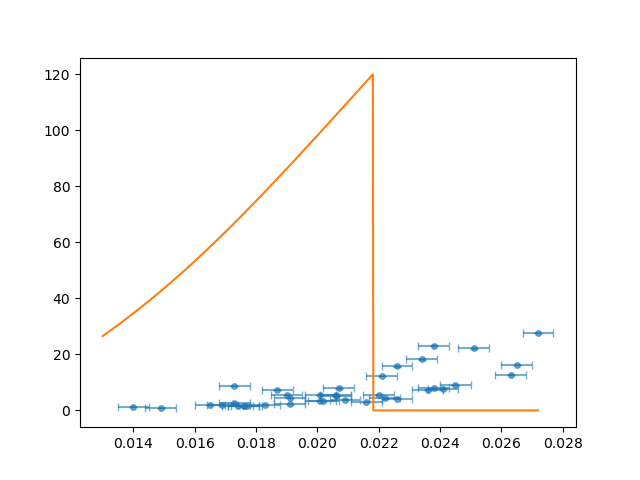

In [66]:
import numpy as np


x = np.array([
    0.0263, 0.0272, 0.0173, 0.0238, 0.0236, 0.0187, 0.0226, 0.0241, 0.0206, 0.0165,
    0.0191, 0.0221, 0.0234, 0.0201, 0.0245, 0.019,  0.0251, 0.0206, 0.0201, 0.0226,
    0.0202, 0.0238, 0.0173, 0.022,  0.0216, 0.0209, 0.014,  0.0183, 0.0207, 0.0265,
    0.0177, 0.0174, 0.0191, 0.0176, 0.0176, 0.0149, 0.0169, 0.0222
])


t = np.array([
    12.73,  27.53,  8.6,    23.13,  7.16,   7.4,    15.67,  7.73,   5.16,   1.9,
    4.4,    12.23,  18.2,   5.53,   9.13,   5.4,    22.1,   5.4,    3.37,   4.21,
    3.33,   8.07,   2.47,   5.63,   3.1,    3.867,  1.2,    2.0,    7.853,  16.118,
    1.7,    1.6,    2.2,    1.63,   1.6,    0.77,   2.0,    4.27
])

x_error=0.0005
t_error=0.04
plt.close('all')
plt.errorbar(x,t,xerr=x_error,yerr=t_error,fmt='o',alpha=0.6,zorder=2,ms=4,capsize=3)


plt.plot(x_plot,t_plot)

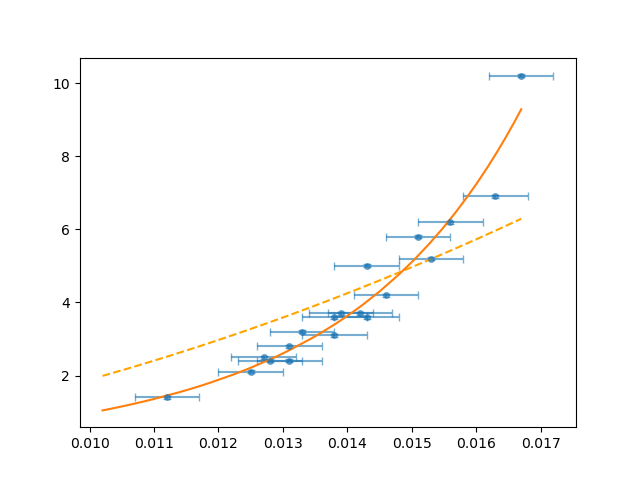

In [68]:
x=np.array([1.12E-02,1.28E-02,1.25E-02,1.38E-02,1.38E-02,1.42E-02,1.39E-02,1.33E-02,1.56E-02,1.43E-02,1.46E-02,1.51E-02,1.67E-02,1.43E-02,1.31E-02,1.31E-02,1.27E-02,1.53E-02,1.63E-02])
t=np.array([1.4,2.4,2.1,3.1,3.6,3.7,3.7,3.2,6.2,5,4.2,5.8,10.2,3.6,2.4,2.8,2.5,5.2,6.9])
plt.close('all')
plt.scatter(x,t)


x_error=0.0005
t_error=0.04
plt.close('all')
plt.errorbar(x,t,xerr=x_error,yerr=t_error,fmt='o',alpha=0.6,zorder=2,ms=4,capsize=3)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import k1
from scipy.optimize import curve_fit
r=0.0024
fun=lambda x,A:A*(x**2-4*(r)**2)
[A1],_=curve_fit(fun,x,t,t_error)
x_plot=np.linspace(np.min(x)-0.001,np.max(x),1000)
plt.plot(x_plot,fun(x_plot,A1),'--',color='orange')
Lc=2.7*10**(-3)
def cheerios_true(x,A,B):
    t=np.zeros(len(x))
    for j in range(len(x)):
        
        dt=0.001
        t_sim=np.arange(0,22,dt)
        x_sim=np.zeros(len(t_sim))
        v_sim=np.zeros(len(t_sim))
        x_sim[0], v_sim[0] = x[j], 0
        for i in range(len(t_sim)-1):
            if x[j]<2*r:
                t[j]=0
                break
            a=-A*v_sim[i]-B*k1(x_sim[i]/Lc)
            v_sim[i+1]=v_sim[i]+a*dt
            x_sim[i+1]=x_sim[i]+v_sim[i]*dt
            if x_sim[i+1]<=2*r:
                t[j]=t_sim[i+1]
                break
    return t
def error_cheerios(params):
    A,B=params
    t_sim=cheerios_true(x,A,B)
    if A <= 0 or B <= 0: 
        return 1e18 
    error=np.sum(((t_sim-t)/t_error)**2)
    return error
initial_gues=2*np.array([0.005128,0.427814])
results=minimize(error_cheerios,initial_gues,method='Nelder-Mead')
A,B=results.x
t_plot=cheerios_true(x_plot,A,B)
plt.plot(x_plot,t_plot)

In [60]:
print(A,B)

2.3803650724253673 0.6825347631467996


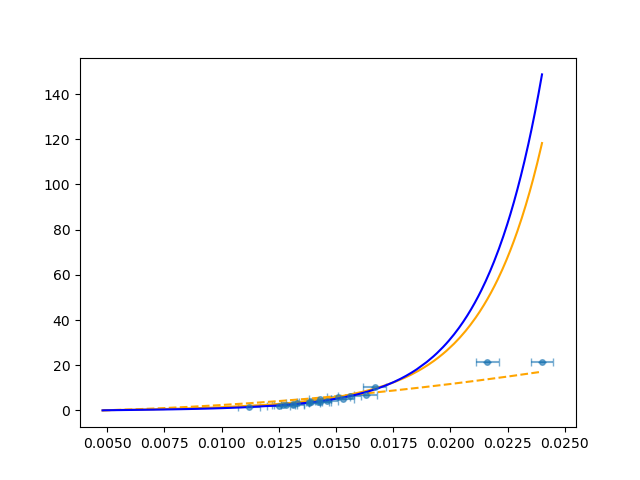

In [97]:
x=np.array([1.12E-02,1.28E-02,1.25E-02,1.38E-02,1.38E-02,1.42E-02,1.39E-02,1.33E-02,1.56E-02,1.43E-02,1.46E-02,1.51E-02,1.67E-02,1.43E-02,1.31E-02,2.40E-02,1.31E-02,1.27E-02,1.53E-02,1.63E-02,2.16E-02])
t=np.array([1.4,2.4,2.1,3.1,3.6,3.7,3.7,3.2,6.2,5,4.2,5.8,10.2,3.6,2.4,21.3,2.8,2.5,5.2,6.9,21.3])
r=0.0024
x_error=0.0005
t_error=0.04
x_plot=np.linspace(2*r,np.max(x),1000)
plt.close('all')
plt.errorbar(x,t,xerr=x_error,yerr=t_error,fmt='o',alpha=0.6,zorder=2,ms=4,capsize=3)
A = 0.6889755356678364 
B= 0.26096569998726427
def cheerios_true(x,A,B):
    t=np.zeros(len(x))
    for j in range(len(x)):
        
        dt=0.01
        t_sim=np.arange(0,240,dt)
        x_sim=np.zeros(len(t_sim))
        v_sim=np.zeros(len(t_sim))
        x_sim[0], v_sim[0] = x[j], 0
        for i in range(len(t_sim)-1):
            if x[j]<2*r:
                t[j]=0
                break
            a=-A*v_sim[i]-B*k1(x_sim[i]/Lc)
            v_sim[i+1]=v_sim[i]+a*dt
            x_sim[i+1]=x_sim[i]+v_sim[i]*dt
            if x_sim[i+1]<=2*r:
                t[j]=t_sim[i+1]
                break
    return t
t_plot=cheerios_true(x_plot,A,B)
plt.plot(x_plot,t_plot,color='orange')
plt.plot(x_plot,fun(x_plot,A1),'--',color='orange')
A=2.3803650724253673 
B=0.6825347631467996
t_plot=cheerios_true(x_plot,A,B)
plt.plot(x_plot,t_plot,color='blue')

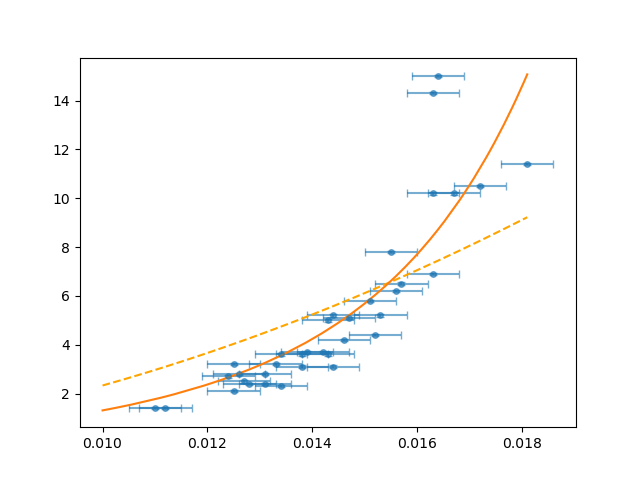

In [98]:
from scipy.optimize import differential_evolution
x=np.array([1.12E-02,1.28E-02,1.25E-02,1.38E-02,1.38E-02,1.42E-02,1.39E-02,1.33E-02,1.56E-02,1.43E-02,1.46E-02,1.51E-02,1.67E-02,1.43E-02,1.31E-02,1.31E-02,1.27E-02,1.53E-02,1.63E-02,1.26E-02,1.24E-02,1.25E-02,1.34E-02,1.47E-02,1.10E-02,1.57E-02,1.34E-02,1.44E-02,1.44E-02,1.64E-02,1.52E-02,1.55E-02,1.63E-02,1.81E-02,1.63E-02,1.72E-02])
t=np.array([1.4,2.4,2.1,3.1,3.6,3.7,3.7,3.2,6.2,5,4.2,5.8,10.2,3.6,2.4,2.8,2.5,5.2,6.9,2.8,2.7,3.2,3.6,5.1,1.4,6.5,2.3,3.1,5.2,15,4.4,7.8,10.2,11.4,14.3,10.5])
plt.close('all')
plt.scatter(x,t)


x_error=0.0005
t_error=0.05
plt.close('all')
plt.errorbar(x,t,xerr=x_error,yerr=t_error,fmt='o',alpha=0.6,zorder=2,ms=4,capsize=3)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import k1
from scipy.optimize import curve_fit
r=0.0024
fun=lambda x,A:A*(x**2-4*(r)**2)
[A1],_=curve_fit(fun,x,t,t_error)
x_plot=np.linspace(np.min(x)-0.001,np.max(x),1000)
plt.plot(x_plot,fun(x_plot,A1),'--',color='orange')
Lc=2.7*10**(-3)
def cheerios_true(x,A,B):
    t=np.zeros(len(x))
    for j in range(len(x)):
        
        dt=0.001
        t_sim=np.arange(0,100,dt)
        x_sim=np.zeros(len(t_sim))
        v_sim=np.zeros(len(t_sim))
        x_sim[0], v_sim[0] = x[j], 0
        for i in range(len(t_sim)-1):
            if x[j]<2*r:
                t[j]=0
                break
            a=-A*v_sim[i]-B*k1(x_sim[i]/Lc)
            v_sim[i+1]=v_sim[i]+a*dt
            x_sim[i+1]=x_sim[i]+v_sim[i]*dt
            if x_sim[i+1]<=2*r:
                t[j]=t_sim[i+1]
                break
    return t
def error_cheerios(params):
    A,B=params
    t_sim=cheerios_true(x,A,B)
    if A <= 0 or B <= 0: 
        return 1e18 
    error=np.sum(((t_sim-t)/t_error)**2)
    return error
global_bounds=[(0,10),(0,10)]

results=differential_evolution(error_cheerios,global_bounds)
A,B=results.x
t_plot=cheerios_true(x_plot,A,B)
plt.plot(x_plot,t_plot)

In [99]:
print(A,B)

0.8705599471300216 0.3052011311203344


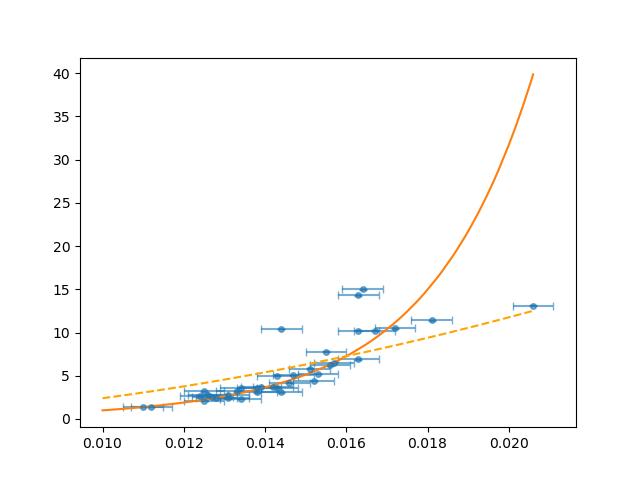

In [74]:
plt.close('all')
plt.errorbar(x,t,xerr=x_error,yerr=t_error,fmt='o',alpha=0.6,zorder=2,ms=4,capsize=3)
A = 2.3803650724253673 
B=0.6825347631467996
def cheerios_true(x,A,B):
    t=np.zeros(len(x))
    for j in range(len(x)):
        
        dt=0.01
        t_sim=np.arange(0,240,dt)
        x_sim=np.zeros(len(t_sim))
        v_sim=np.zeros(len(t_sim))
        x_sim[0], v_sim[0] = x[j], 0
        for i in range(len(t_sim)-1):
            if x[j]<2*r:
                t[j]=0
                break
            a=-A*v_sim[i]-B*k1(x_sim[i]/Lc)
            v_sim[i+1]=v_sim[i]+a*dt
            x_sim[i+1]=x_sim[i]+v_sim[i]*dt
            if x_sim[i+1]<=2*r:
                t[j]=t_sim[i+1]
                break
    return t
t_plot=cheerios_true(x_plot,A,B)
plt.plot(x_plot,t_plot)
plt.plot(x_plot,fun(x_plot,A1),'--',color='orange')

Text(0.5, 1.0, 'Interaction between particle A (concave up) and particle B (concave down)')

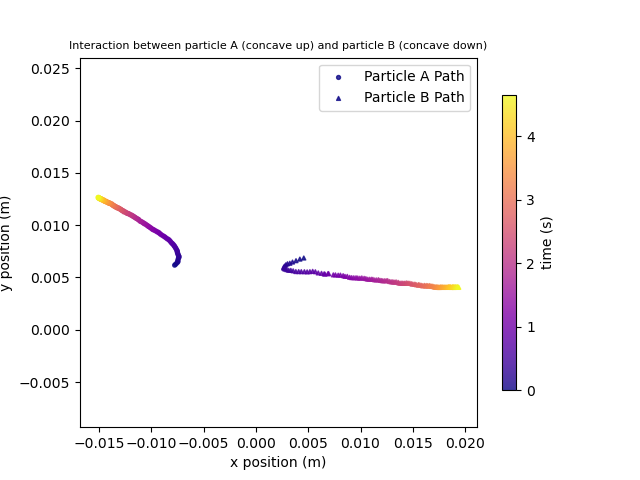

In [161]:
import numpy as np
import matplotlib.pyplot as plt
matrix = np.loadtxt(
    'DATA COLLISION A.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)


t1 = matrix[:, 0][:-20]
x1 = matrix[:, 1][:-20]
y1 = matrix[:, 2][:-20]

import numpy as np
import matplotlib.pyplot as plt
matrix = np.loadtxt(
    'DATA COLLISION B.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)


t2 = matrix[:, 0][:-20]
x2 = matrix[:, 1][:-20]
y2 = matrix[:, 2][:-20]

plt.close('all')
sc1 = plt.scatter(x1, y1, alpha=0.8,c=t1, cmap='plasma',marker='o', s=8, label="Particle A Path")
sc2 = plt.scatter(x2, y2, alpha=0.8,c=t2, cmap='plasma',marker='^', s=8, label="Particle B Path")
plt.colorbar(sc1,label='time (s)',shrink=0.8)
plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.axis('equal')
plt.legend()
plt.title(r'Interaction between particle A (concave up) and particle B (concave down)',fontsize=8)

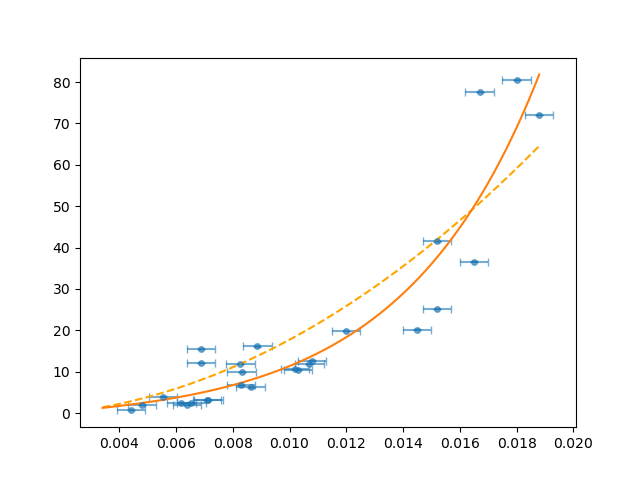

In [125]:
plt.close('all')
x=np.array([4.41E-03,6.88E-03,8.27E-03,5.55E-03,4.79E-03,6.19E-03,6.87E-03,6.54E-03,8.31E-03,8.87E-03,8.29E-03,8.63E-03,7.10E-03,7.14E-03,6.38E-03,1.07E-02,1.08E-02,1.03E-02,1.20E-02,1.02E-02,1.52E-02,1.80E-02,1.45E-02,1.65E-02,1.88E-02,1.67E-02,1.52E-02])
t=np.array([0.7,15.5,11.87,4,1.9,2.4,12.1,2.5,9.9,16.1,6.8,6.2,3.1,3.1,1.9,11.8,12.7,10.4,19.8,10.7,25.2,80.5,20.2,36.6,72.1,77.6,41.5])
x_error=0.0005
t_error=0.05
plt.close('all')
plt.errorbar(x,t,xerr=x_error,yerr=t_error,fmt='o',alpha=0.6,zorder=2,ms=4,capsize=3)
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import k1
from scipy.optimize import curve_fit
r=0.001
fun=lambda x,A:A*(x**2-4*(r)**2)
[A1],_=curve_fit(fun,x,t,t_error)
x_plot=np.linspace(np.min(x)-0.001,np.max(x),1000)
plt.plot(x_plot,fun(x_plot,A1),'--',color='orange')
Lc=2.7*10**(-3)
def cheerios_true(x,A,B):
    t=np.zeros(len(x))
    for j in range(len(x)):
        
        dt=0.001
        t_sim=np.arange(0,100,dt)
        x_sim=np.zeros(len(t_sim))
        v_sim=np.zeros(len(t_sim))
        x_sim[0], v_sim[0] = x[j], 0
        for i in range(len(t_sim)-1):
            if x[j]<2*r:
                t[j]=0
                break
            a=-A*v_sim[i]-B*k1(x_sim[i]/Lc)
            v_sim[i+1]=v_sim[i]+a*dt
            x_sim[i+1]=x_sim[i]+v_sim[i]*dt
            if x_sim[i+1]<=2*r:
                t[j]=t_sim[i+1]
                break
    return t
def error_cheerios(params):
    A,B=params
    t_sim=cheerios_true(x,A,B)
    if A <= 0 or B <= 0: 
        return 1e18 
    error=np.sum(((t_sim-t)/t_error)**2)
    return error
global_bounds=[(0,10),(0,10)]

results=differential_evolution(error_cheerios,global_bounds)
A,B=results.x
t_plot=cheerios_true(x_plot,A,B)
plt.plot(x_plot,t_plot)

Text(0.5, 1.0, 'Interaction between particle A (concave down) and particle B (concave down)')

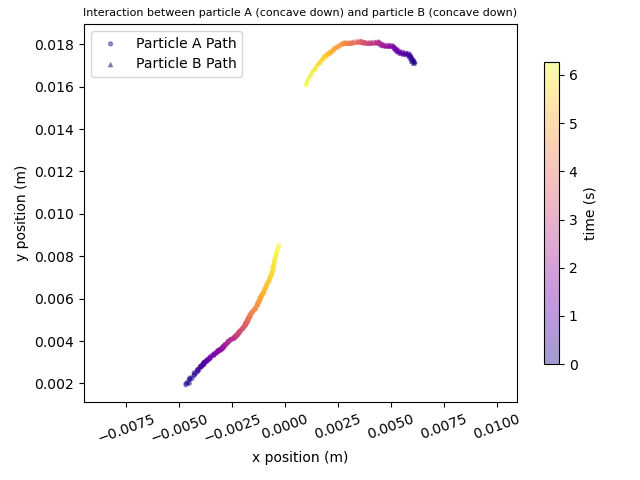

In [160]:
import numpy as np
import matplotlib.pyplot as plt
matrix = np.loadtxt(
    'DATA COLLISION A1.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)


t1 = matrix[:, 0][:-55]
x1 = matrix[:, 1][:-55]
y1 = matrix[:, 2][:-55]

import numpy as np
import matplotlib.pyplot as plt
matrix = np.loadtxt(
    'DATA COLLISION B1.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)


t2 = matrix[:, 0][:-55]
x2 = matrix[:, 1][:-55]
y2 = matrix[:, 2][:-55]

plt.close('all')
sc1 = plt.scatter(x1, y1, alpha=0.4,c=t1, cmap='plasma',marker='o', s=8, label="Particle A Path")
sc2 = plt.scatter(x2, y2, alpha=0.4,c=t2, cmap='plasma',marker='^', s=8, label="Particle B Path")
plt.colorbar(sc1,label='time (s)',shrink=0.8)
plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.axis('equal')
plt.xticks(rotation=20)
plt.legend()

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.title(r'Interaction between particle A (concave down) and particle B (concave down)',fontsize=8)

Text(0.5, 1.0, 'Interaction between particle A (concave up) and particle B (concave up)')

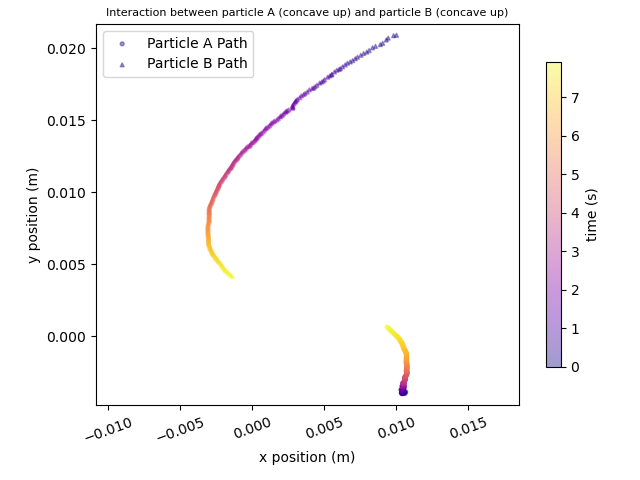

In [176]:
import numpy as np
import matplotlib.pyplot as plt
matrix = np.loadtxt(
    'DATA COLLISION A2.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)


t1 = matrix[:, 0][:-60]
x1 = matrix[:, 1][:-60]
y1 = matrix[:, 2][:-60]

import numpy as np
import matplotlib.pyplot as plt
matrix = np.loadtxt(
    'DATA COLLISION B2.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)


t2 = matrix[:, 0][:-60]
x2 = matrix[:, 1][:-60]
y2 = matrix[:, 2][:-60]

plt.close('all')
sc1 = plt.scatter(x1, y1, alpha=0.4,c=t1, cmap='plasma',marker='o', s=8, label="Particle A Path")
sc2 = plt.scatter(x2, y2, alpha=0.4,c=t2, cmap='plasma',marker='^', s=8, label="Particle B Path")
plt.colorbar(sc1,label='time (s)',shrink=0.8)
plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.axis('equal')
plt.xticks(rotation=20)
plt.legend()

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.title(r'Interaction between particle A (concave up) and particle B (concave up)',fontsize=8)

Text(0.5, 1.0, 'Interaction between particle A (concave up) and wall')

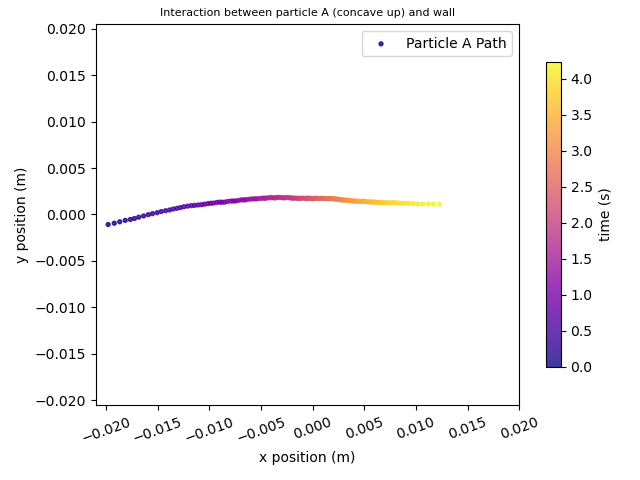

In [190]:
import numpy as np
import matplotlib.pyplot as plt
matrix = np.loadtxt(
    'DATA COLLISION A3.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)

plt.close('all')
t1 = matrix[:, 0][:-1]
x1 = matrix[:, 1][:-1]
y1 = matrix[:, 2][:-1]
sc1 = plt.scatter(x1, y1, alpha=0.8,c=t1, cmap='plasma',marker='o', s=8, label="Particle A Path")
plt.colorbar(sc1,label='time (s)',shrink=0.8)
plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.xlim(-0.021,0.020)
plt.ylim(-0.0205,0.0205)
plt.xticks(rotation=20)
plt.legend()

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.title(r'Interaction between particle A (concave up) and wall',fontsize=8)

Text(0.5, 1.0, 'Interaction between particle A (concave down) and wall')

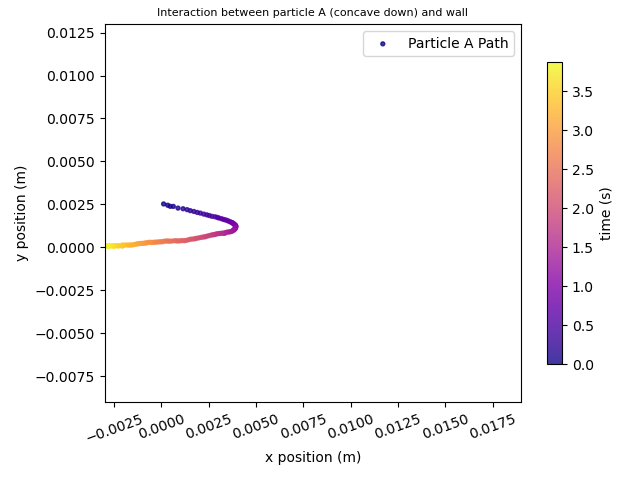

In [192]:
import numpy as np
import matplotlib.pyplot as plt
matrix = np.loadtxt(
    'DATA COLLISION A4.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)

plt.close('all')
t1 = matrix[:, 0]
x1 = matrix[:, 1]
y1 = matrix[:, 2]
sc1 = plt.scatter(x1, y1, alpha=0.8,c=t1, cmap='plasma',marker='o', s=8, label="Particle A Path")
plt.colorbar(sc1,label='time (s)',shrink=0.8)
plt.xlabel("x position (m)")
plt.ylabel("y position (m)")
plt.xlim(-0.003,0.019)
plt.ylim(-0.009,0.013)
plt.xticks(rotation=20)
plt.legend()

plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.title(r'Interaction between particle A (concave down) and wall',fontsize=8)

0.25213554836499275 0.5729428724962983 -0.0016658189835680683
0.007406746439895738 0.016336548774659003
12.667


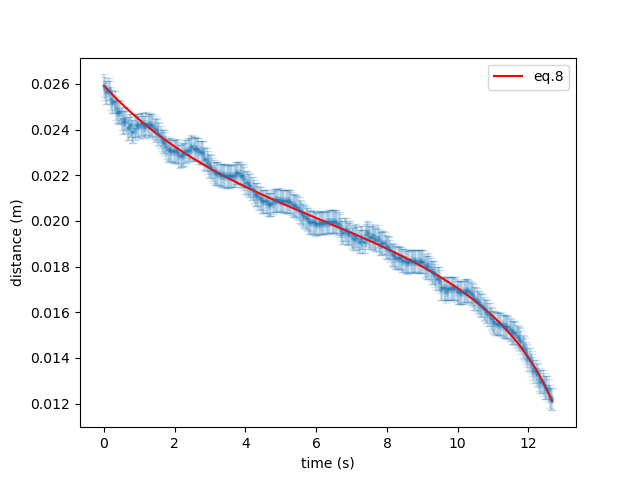

In [290]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import k1
from scipy.optimize import differential_evolution
matrix = np.loadtxt(
    'DATA VIDEO 1.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)
plt.close('all')
t = matrix[:, 0][:-103]
x = matrix[:, 1][:-103]
y = matrix[:, 2][:-103]
r=np.sqrt(x**2+y**2)
Lc=2.7*10**(-3)
t_end=t[-1]
def cheerios_true(t_data,A,B,v0):
    dt=0.001
    t=np.arange(0,t_end+dt/2,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], v0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
def error(params):
    A_param,B_param,v_param=params
    r_sim=cheerios_true(t,A_param,B_param,v_param)
    return np.sum((r_sim-r)**2)
bounds=[(0,10),(0,10),(-0.01,0.01)]
results=differential_evolution(error,bounds)
A,B,v0=results.x
gues=[A,B,v0]
popt,pcov=curve_fit(cheerios_true,t,r,p0=gues,sigma=x_error)
A,B,v0=popt
error_A,error_B,_=np.sqrt(np.diag(pcov))
print(A,B,v0)
print(error_A,error_B)
plt.errorbar(t,r,xerr=t_error,yerr=x_error,fmt='o',alpha=0.2,zorder=2,ms=2,capsize=3)

t1,x1=cheerios_true(None,A,B,v0)
plt.plot(t1,x1,'r',label='eq.8')
plt.xlabel('time (s)')
plt.ylabel('distance (m)')
plt.legend()
print(t[-1])

0.10689042304218978 0.38412721814664696 -0.0006114289414470528
0.0024029746495478795 0.006747118771762336
27.533


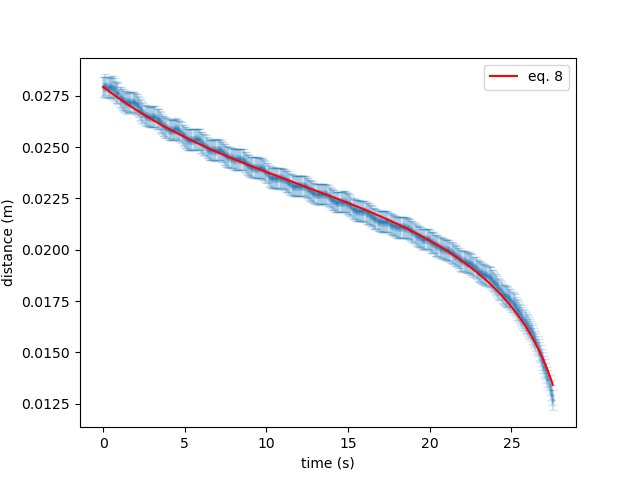

In [291]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import k1
from scipy.optimize import differential_evolution
matrix = np.loadtxt(
    'DATA VIDEO 3.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)
plt.close('all')
t = matrix[:, 0][:-178][::2]
x = matrix[:, 1][:-178][::2]
y = matrix[:, 2][:-178][::2]
r=np.sqrt(x**2+y**2)
Lc=2.7*10**(-3)
t_end=t[-1]
def cheerios_true(t_data,A,B,v0):
    dt=0.001
    t=np.arange(0,t_end+dt/2,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], v0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
def error(params):
    A_param,B_param,v_param=params
    r_sim=cheerios_true(t,A_param,B_param,v_param)
    return np.sum((r_sim-r)**2)
bounds=[(0,2),(0,2),(-0.01,0.01)]
results=differential_evolution(error,bounds)
A,B,v0=results.x
gues=[A,B,v0]
popt,pcov=curve_fit(cheerios_true,t,r,p0=gues,sigma=x_error)
A,B,v0=popt
error_A,error_B,_=np.sqrt(np.diag(pcov))
print(A,B,v0)
print(error_A,error_B)
plt.errorbar(t,r,xerr=t_error,yerr=x_error,fmt='o',alpha=0.2,zorder=1,ms=2,capsize=3)
plt.xlabel('time (s)')
plt.ylabel('distance (m)')

t1,x1=cheerios_true(None,A,B,v0)
plt.plot(t1,x1,'r',label='eq. 8')
plt.legend()
print(t[-1])

0.737788337277756 1.4243405425216633 -0.0007206616590489708
0.0370989534942029 0.053004584125945234
8.633


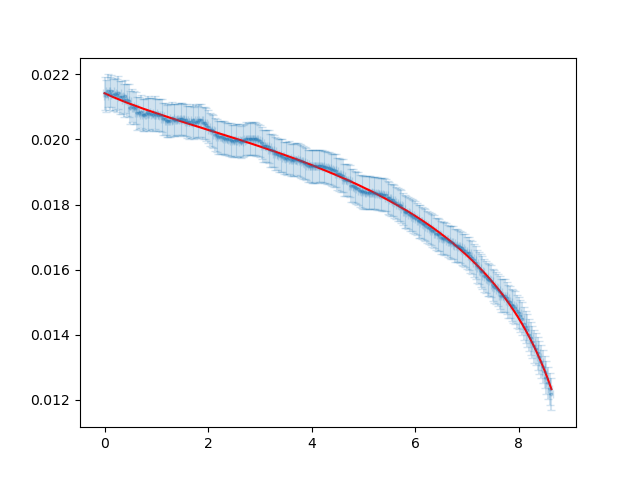

In [227]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import k1
from scipy.optimize import differential_evolution
matrix = np.loadtxt(
    'DATA VIDEO 4.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)
plt.close('all')
t = matrix[:, 0][:-4]
x = matrix[:, 1][:-4]
y = matrix[:, 2][:-4]
r=np.sqrt(x**2+y**2)
Lc=2.7*10**(-3)
t_end=t[-1]
def cheerios_true(t_data,A,B,v0):
    dt=0.001
    t=np.arange(0,t_end+dt/2,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], v0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
def error(params):
    A_param,B_param,v_param=params
    r_sim=cheerios_true(t,A_param,B_param,v_param)
    return np.sum((r_sim-r)**2)
bounds=[(0,2),(0,2),(-0.01,0.01)]
results=differential_evolution(error,bounds)
A,B,v0=results.x
gues=[A,B,v0]
popt,pcov=curve_fit(cheerios_true,t,r,p0=gues,sigma=x_error)
A,B,v0=popt
error_A,error_B,_=np.sqrt(np.diag(pcov))
print(A,B,v0)
print(error_A,error_B)
plt.errorbar(t,r,xerr=t_error,yerr=x_error,fmt='o',alpha=0.2,zorder=2,ms=2,capsize=3)

t1,x1=cheerios_true(None,A,B,v0)
plt.plot(t1,x1,'r',label='eq. 7')
print(t[-1])

1.7661251892281102 1.81704237134829 -0.0010944514451531968
0.06920075223380986 0.0646151499481183
23.1


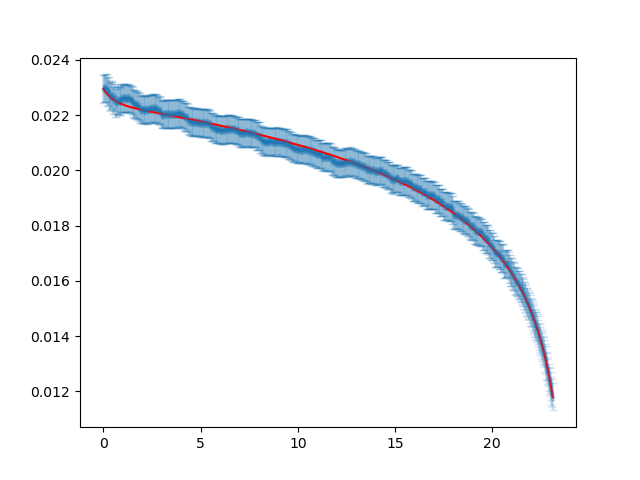

In [229]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import k1
from scipy.optimize import differential_evolution
matrix = np.loadtxt(
    'DATA VIDEO 5.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)
plt.close('all')
t = matrix[:, 0][:-5]
x = matrix[:, 1][:-5]
y = matrix[:, 2][:-5]
r=np.sqrt(x**2+y**2)
Lc=2.7*10**(-3)
t_end=t[-1]
def cheerios_true(t_data,A,B,v0):
    dt=0.001
    t=np.arange(0,t_end+dt/2,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], v0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
def error(params):
    A_param,B_param,v_param=params
    r_sim=cheerios_true(t,A_param,B_param,v_param)
    return np.sum((r_sim-r)**2)
bounds=[(0,2),(0,2),(-0.01,0.01)]
results=differential_evolution(error,bounds)
A,B,v0=results.x
gues=[A,B,v0]
popt,pcov=curve_fit(cheerios_true,t,r,p0=gues,sigma=x_error)
A,B,v0=popt
error_A,error_B,_=np.sqrt(np.diag(pcov))
print(A,B,v0)
print(error_A,error_B)
plt.errorbar(t,r,xerr=t_error,yerr=x_error,fmt='o',alpha=0.2,zorder=2,ms=2,capsize=3)

t1,x1=cheerios_true(None,A,B,v0)
plt.plot(t1,x1,'r',label='eq. 7')
print(t[-1])

0.6028449517737052 1.1260851718437281 -0.0026818681152697946
0.017786776292506794 0.036431356783452544
7.2


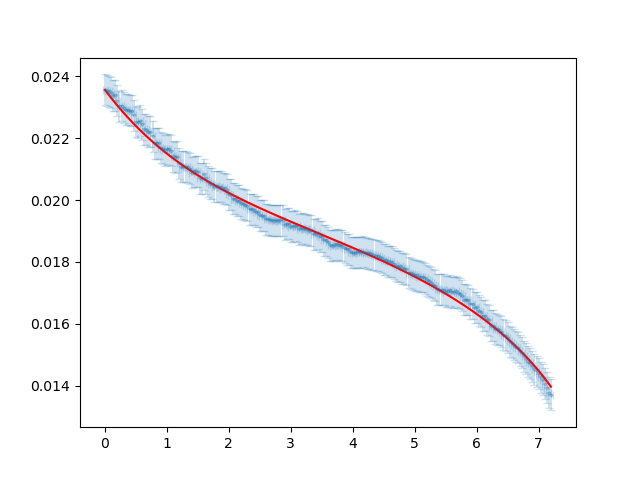

In [235]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import k1
from scipy.optimize import differential_evolution
matrix = np.loadtxt(
    'DATA VIDEO 7.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)
plt.close('all')
t = matrix[:, 0][:-30]
x = matrix[:, 1][:-30]
y = matrix[:, 2][:-30]
r=np.sqrt(x**2+y**2)
Lc=2.7*10**(-3)
t_end=t[-1]
def cheerios_true(t_data,A,B,v0):
    dt=0.001
    t=np.arange(0,t_end+dt/2,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], v0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
def error(params):
    A_param,B_param,v_param=params
    r_sim=cheerios_true(t,A_param,B_param,v_param)
    return np.sum((r_sim-r)**2)
bounds=[(0,2),(0,2),(-0.01,0.01)]
results=differential_evolution(error,bounds)
A,B,v0=results.x
gues=[A,B,v0]
popt,pcov=curve_fit(cheerios_true,t,r,p0=gues,sigma=x_error)
A,B,v0=popt
error_A,error_B,_=np.sqrt(np.diag(pcov))
print(A,B,v0)
print(error_A,error_B)
plt.errorbar(t,r,xerr=t_error,yerr=x_error,fmt='o',alpha=0.2,zorder=2,ms=2,capsize=3)

t1,x1=cheerios_true(None,A,B,v0)
plt.plot(t1,x1,'r',label='eq. 7')
print(t[-1])

1.0703929152740561 2.32343555098074 0.0006456629096183209
0.15455139774279 0.23736840520719074
7.4


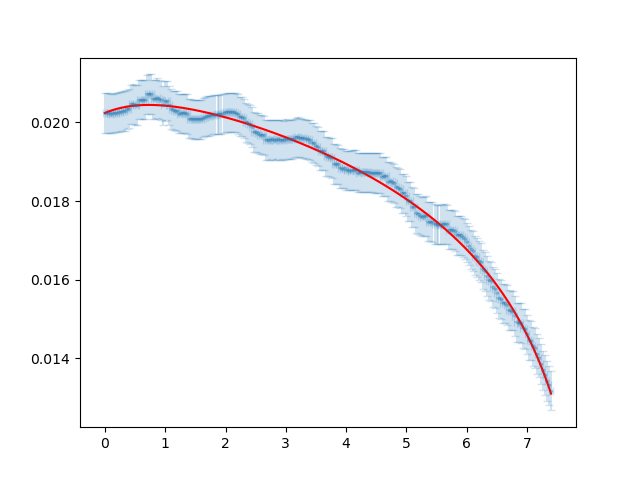

In [239]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import k1
from scipy.optimize import differential_evolution
matrix = np.loadtxt(
    'DATA VIDEO 8.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)
plt.close('all')
t = matrix[:, 0][:-49]
x = matrix[:, 1][:-49]
y = matrix[:, 2][:-49]
r=np.sqrt(x**2+y**2)
Lc=2.7*10**(-3)
t_end=t[-1]
def cheerios_true(t_data,A,B,v0):
    dt=0.001
    t=np.arange(0,t_end+dt/2,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], v0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
def error(params):
    A_param,B_param,v_param=params
    r_sim=cheerios_true(t,A_param,B_param,v_param)
    return np.sum((r_sim-r)**2)
bounds=[(0,2),(0,2),(-0.01,0.01)]
results=differential_evolution(error,bounds)
A,B,v0=results.x
gues=[A,B,v0]
popt,pcov=curve_fit(cheerios_true,t,r,p0=gues,sigma=x_error)
A,B,v0=popt
error_A,error_B,_=np.sqrt(np.diag(pcov))
print(A,B,v0)
print(error_A,error_B)
plt.errorbar(t,r,xerr=t_error,yerr=x_error,fmt='o',alpha=0.2,zorder=2,ms=2,capsize=3)

t1,x1=cheerios_true(None,A,B,v0)
plt.plot(t1,x1,'r',label='eq. 7')
print(t[-1])

0.08418802204960303 0.37167602576331304 -0.0001854422522533021
0.016463761103737744 0.0247253441140955
15.667


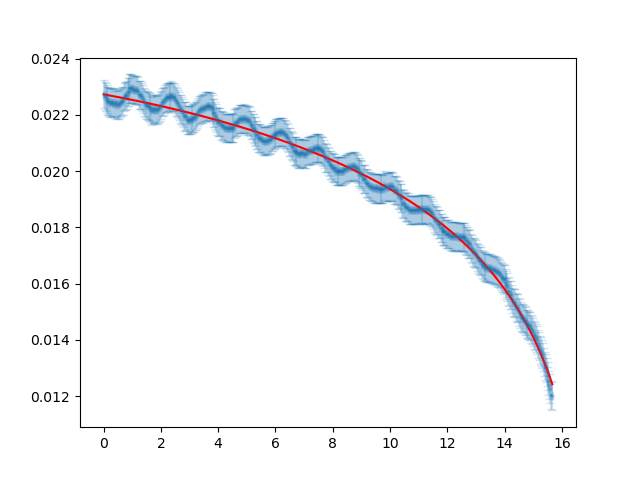

In [245]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import k1
from scipy.optimize import differential_evolution
matrix = np.loadtxt(
    'DATA VIDEO 9.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)
plt.close('all')
t = matrix[:, 0][:-65]
x = matrix[:, 1][:-65]
y = matrix[:, 2][:-65]
r=np.sqrt(x**2+y**2)
Lc=2.7*10**(-3)
t_end=t[-1]
def cheerios_true(t_data,A,B,v0):
    dt=0.001
    t=np.arange(0,t_end+dt/2,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], v0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
def error(params):
    A_param,B_param,v_param=params
    r_sim=cheerios_true(t,A_param,B_param,v_param)
    return np.sum((r_sim-r)**2)
bounds=[(0,2),(0,2),(-0.01,0.01)]
results=differential_evolution(error,bounds)
A,B,v0=results.x
gues=[A,B,v0]
popt,pcov=curve_fit(cheerios_true,t,r,p0=gues,sigma=x_error)
A,B,v0=popt
error_A,error_B,_=np.sqrt(np.diag(pcov))
print(A,B,v0)
print(error_A,error_B)
plt.errorbar(t,r,xerr=t_error,yerr=x_error,fmt='o',alpha=0.2,zorder=2,ms=2,capsize=3)

t1,x1=cheerios_true(None,A,B,v0)
plt.plot(t1,x1,'r',label='eq. 7')
print(t[-1])

0.06385540139448287 0.7362234046499277 -0.0009385342980009237
0.005427024127586178 0.01791127388375287
7.733


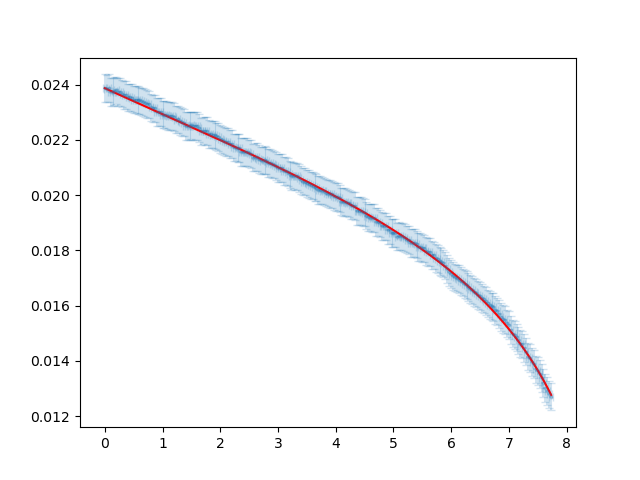

In [249]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import k1
from scipy.optimize import differential_evolution
matrix = np.loadtxt(
    'DATA VIDEO 10.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)
plt.close('all')
t = matrix[:, 0][:-35]
x = matrix[:, 1][:-35]
y = matrix[:, 2][:-35]
r=np.sqrt(x**2+y**2)
Lc=2.7*10**(-3)
t_end=t[-1]
def cheerios_true(t_data,A,B,v0):
    dt=0.001
    t=np.arange(0,t_end+dt/2,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], v0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
def error(params):
    A_param,B_param,v_param=params
    r_sim=cheerios_true(t,A_param,B_param,v_param)
    return np.sum((r_sim-r)**2)
bounds=[(0,2),(0,2),(-0.01,0.01)]
results=differential_evolution(error,bounds)
A,B,v0=results.x
gues=[A,B,v0]
popt,pcov=curve_fit(cheerios_true,t,r,p0=gues,sigma=x_error)
A,B,v0=popt
error_A,error_B,_=np.sqrt(np.diag(pcov))
print(A,B,v0)
print(error_A,error_B)
plt.errorbar(t,r,xerr=t_error,yerr=x_error,fmt='o',alpha=0.2,zorder=2,ms=2,capsize=3)

t1,x1=cheerios_true(None,A,B,v0)
plt.plot(t1,x1,'r',label='eq. 7')
print(t[-1])

6.450487788314766e-05 0.6387978552678683
-0.10336644348464374 0.44130806383852106 -0.0006411848548181227
0.047907762318939326 0.09137302351144834
5.133


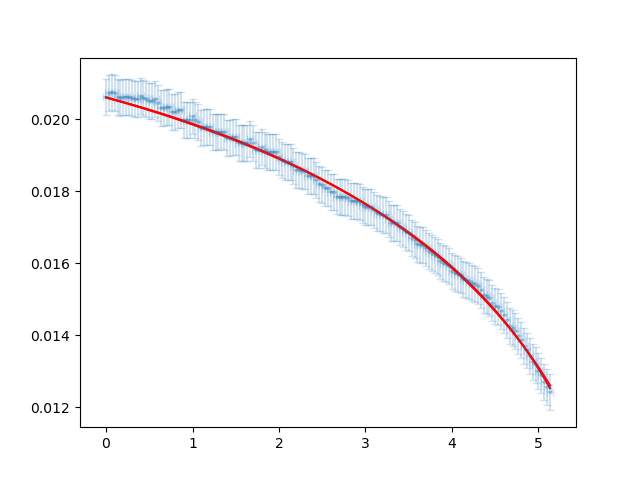

In [259]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import k1
from scipy.optimize import differential_evolution
matrix = np.loadtxt(
    'DATA VIDEO 11.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)
plt.close('all')
t = matrix[:, 0][:-48]
x = matrix[:, 1][:-48]
y = matrix[:, 2][:-48]
r=np.sqrt(x**2+y**2)
Lc=2.7*10**(-3)
t_end=t[-1]
def cheerios_true(t_data,A,B,v0):
    dt=0.001
    t=np.arange(0,t_end+dt/2,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], v0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
def error(params):
    A_param,B_param,v_param=params
    r_sim=cheerios_true(t,A_param,B_param,v_param)
    return np.sum((r_sim-r)**2)
bounds=[(0,2),(0,2),(-0.01,0.01)]
results=differential_evolution(error,bounds)
A,B,v0=results.x
gues=[A,B,v0]
print(A,B)
t1,x1=cheerios_true(None,A,B,v0)
plt.plot(t1,x1,'r',label='eq. 7')
popt,pcov=curve_fit(cheerios_true,t,r,p0=gues,sigma=x_error)
A,B,v0=popt
error_A,error_B,_=np.sqrt(np.diag(pcov))
print(A,B,v0)
print(error_A,error_B)
plt.errorbar(t,r,xerr=t_error,yerr=x_error,fmt='o',alpha=0.2,zorder=2,ms=2,capsize=3)

t1,x1=cheerios_true(None,A,B,v0)
plt.plot(t1,x1,'r',label='eq. 7')
print(t[-1])

1.9972099924391737 1.7311119791432865
2.0871075912618973 1.774437996516461
0.5076216554526152 0.23755991814042632
1.9


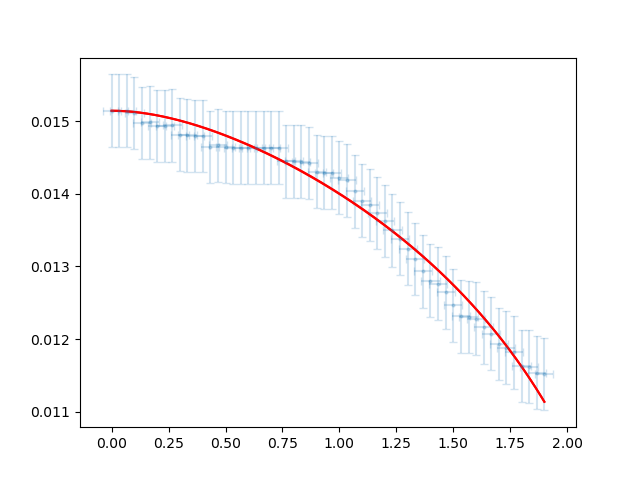

In [269]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import k1
from scipy.optimize import differential_evolution
matrix = np.loadtxt(
    'DATA VIDEO 12.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)
plt.close('all')
t = matrix[:, 0][:-17]
x = matrix[:, 1][:-17]
y = matrix[:, 2][:-17]
r=np.sqrt(x**2+y**2)
Lc=2.7*10**(-3)
t_end=t[-1]
def cheerios_true(t_data,A,B):
    dt=0.001
    t=np.arange(0,t_end+dt/2,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], 0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
def error(params):
    A_param,B_param=params
    r_sim=cheerios_true(t,A_param,B_param)
    return np.sum((r_sim-r)**2)
bounds=[(0,2),(0,2)]
results=differential_evolution(error,bounds)
A,B=results.x
gues=[A,B]
print(A,B)
t1,x1=cheerios_true(None,A,B)
plt.plot(t1,x1,'r',label='eq. 7')
popt,pcov=curve_fit(cheerios_true,t,r,p0=gues,sigma=x_error)
A,B=popt
error_A,error_B=np.sqrt(np.diag(pcov))
print(A,B)
print(error_A,error_B)
plt.errorbar(t,r,xerr=t_error,yerr=x_error,fmt='o',alpha=0.2,zorder=2,ms=2,capsize=3)

t1,x1=cheerios_true(None,A,B)
plt.plot(t1,x1,'r',label='eq. 7')
print(t[-1])

4.81863580277585e-05 1.9999907576136122
0.14480590030044996 2.810616048726111 -0.0009084662590546315
0.03456429840774996 0.12894455726108958
3.333


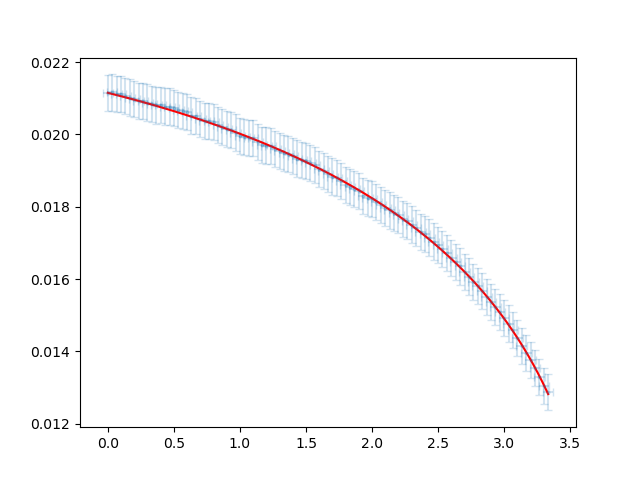

In [289]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import k1
from scipy.optimize import differential_evolution
matrix = np.loadtxt(
    'DATA VIDEO 26.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)
plt.close('all')
t = matrix[:, 0][:-31]
x = matrix[:, 1][:-31]
y = matrix[:, 2][:-31]
r=np.sqrt(x**2+y**2)
Lc=2.7*10**(-3)
t_end=t[-1]
Lc=2.7*10**(-3)
t_end=t[-1]
def cheerios_true(t_data,A,B,v0):
    dt=0.001
    t=np.arange(0,t_end+dt/2,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], v0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
def error(params):
    A_param,B_param,v_param=params
    r_sim=cheerios_true(t,A_param,B_param,v_param)
    return np.sum((r_sim-r)**2)
bounds=[(0,2),(0,2),(-0.01,0.01)]
results=differential_evolution(error,bounds)
A,B,v0=results.x
gues=[A,B,v0]
print(A,B)

popt,pcov=curve_fit(cheerios_true,t,r,p0=gues,sigma=x_error)
A,B,v0=popt
error_A,error_B,_=np.sqrt(np.diag(pcov))
print(A,B,v0)
print(error_A,error_B)
plt.errorbar(t,r,xerr=t_error,yerr=x_error,fmt='o',alpha=0.2,zorder=2,ms=2,capsize=3)

t1,x1=cheerios_true(None,A,B,v0)
plt.plot(t1,x1,'r',label='eq. 7')

print(t[-1])

-0.0024424503996716487
-0.002198205359704484
0.5494047673817967 1.5269292713641134
0.010328178994794504 0.07296396207743495
10.167


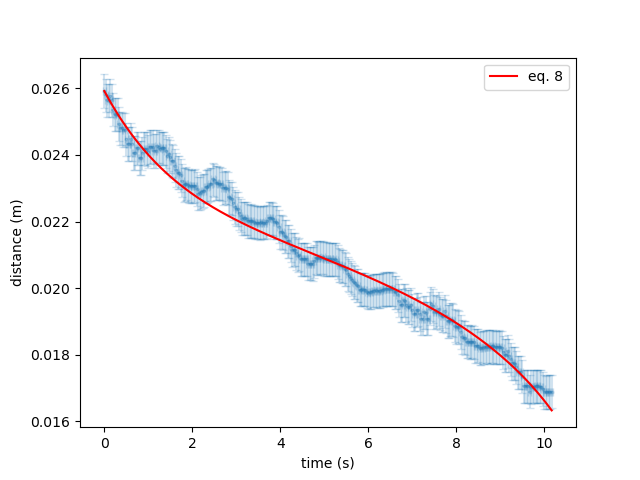

In [306]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import k1
from scipy.optimize import differential_evolution
matrix = np.loadtxt(
    'DATA VIDEO 1.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)
plt.close('all')
t = matrix[:, 0][:-178]
x = matrix[:, 1][:-178]
y = matrix[:, 2][:-178]
r=np.sqrt(x**2+y**2)
Lc=2.7*10**(-3)
t_end=t[-1]
v0_gues = np.polyfit(t[:10], r[:10], 1)[0]
print(v0_gues)
def cheerios_true(t_data,A,B,v0):
    dt=0.001
    t=np.arange(0,t_end+dt/2,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], v0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
def error(params):
    A_param,B_param,v_param=params
    r_sim=cheerios_true(t,A_param,B_param,v_param)
    return np.sum((r_sim-r)**2)
bounds=[(0,2),(0,2),(1.1*v0_gues,0.9*v0_gues)]
results=differential_evolution(error,bounds)


A,B,v0=results.x
print(v0)
def cheerios_true(t_data,A,B):
    dt=1/30
    t=np.arange(0,t_end+dt/2,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], v0_gues
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
gues=[A,B]
popt,pcov=curve_fit(cheerios_true,t,r,p0=gues,sigma=x_error,absolute_sigma=True)
A,B=popt
error_A,error_B=np.sqrt(np.diag(pcov))
print(A,B)
print(error_A,error_B)
plt.errorbar(t,r,xerr=t_error,yerr=x_error,fmt='o',alpha=0.2,zorder=1,ms=2,capsize=3)
plt.xlabel('time (s)')
plt.ylabel('distance (m)')

t1,x1=cheerios_true(None,A,B)
plt.plot(t1,x1,'r',label='eq. 8')
plt.legend()
print(t[-1])

-0.00022184793632595623
-0.0002439109352156803
60.13287113778355 160.2525050694411
4.169565496276346 13.350873451604508
2.833


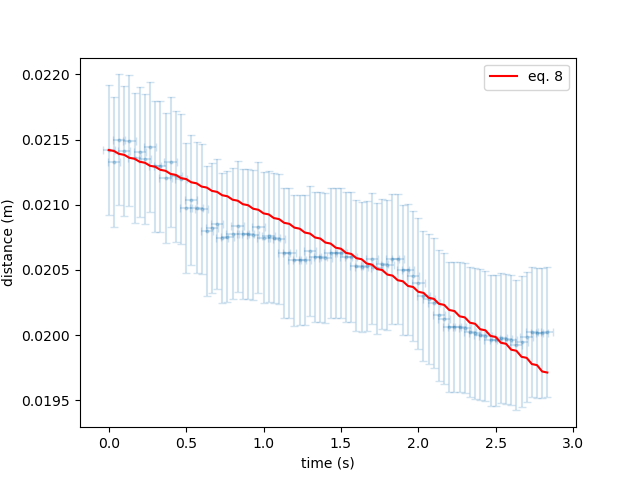

In [307]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.special import k1
from scipy.optimize import differential_evolution
matrix = np.loadtxt(
    'DATA VIDEO 4.txt', 
    skiprows=2, 
    converters=lambda s: float(s.replace(',', '.'))
)
plt.close('all')
t = matrix[:, 0][:-178]
x = matrix[:, 1][:-178]
y = matrix[:, 2][:-178]
r=np.sqrt(x**2+y**2)
Lc=2.7*10**(-3)
t_end=t[-1]
v0_gues = np.polyfit(t[:10], r[:10], 1)[0]
print(v0_gues)
def cheerios_true(t_data,A,B,v0):
    dt=0.001
    t=np.arange(0,t_end+dt/2,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], v0
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
def error(params):
    A_param,B_param,v_param=params
    r_sim=cheerios_true(t,A_param,B_param,v_param)
    return np.sum((r_sim-r)**2)
bounds=[(0,2),(0,2),(1.1*v0_gues,0.9*v0_gues)]
results=differential_evolution(error,bounds)


A,B,v0=results.x
print(v0)
def cheerios_true(t_data,A,B):
    dt=1/30
    t=np.arange(0,t_end+dt/2,dt)
    x=np.zeros(len(t))
    v=np.zeros(len(t))
    x[0], v[0] = r[0], v0_gues
    for i in range(len(t)-1):
        a=-A*v[i]-B*k1(x[i]/Lc)
        v[i+1]=v[i]+a*dt
        x[i+1]=x[i]+v[i]*dt
        if x[i+1]<=0:
            break
    if t_data is not None:
        return np.interp(t_data,t,x)
    return t,x
gues=[A,B]
popt,pcov=curve_fit(cheerios_true,t,r,p0=gues,sigma=x_error,absolute_sigma=True)
A,B=popt
error_A,error_B=np.sqrt(np.diag(pcov))
print(A,B)
print(error_A,error_B)
plt.errorbar(t,r,xerr=t_error,yerr=x_error,fmt='o',alpha=0.2,zorder=1,ms=2,capsize=3)
plt.xlabel('time (s)')
plt.ylabel('distance (m)')

t1,x1=cheerios_true(None,A,B)
plt.plot(t1,x1,'r',label='eq. 8')
plt.legend()
print(t[-1])